# Case study: Bài toán phân tích, dự báo khách hàng rời bỏ dịch vụ của ngân hàng

**Problem Statement:**

Các ngân hàng đều muốn giữ chân khách hàng của mình để duy trì hoạt động kinh doanh và ngân hàng Đa quốc gia ABC cũng muốn điều đó. Dưới đây là dữ liệu khách hàng của các khách hàng tại Ngân hàng Đa quốc gia ABC có phát sinh giao dịch và mục đích của dữ liệu sẽ là dự đoán Tỷ lệ khách hàng rời bỏ.

Giả sử bạn là Data Analyst cho ngân hàng ABC. BOD đang cố gắng tìm hiểu xem tại sao lại xảy ra vấn đề trên và liệu người dùng các dịch vụ có rời bỏ ABC hay không (hủy sử dụng dịch vụ) trong vài ngày tới.

**Objective:**
Bạn được yêu cầu xây dựng một mô hình dự đoán khách hàng sẽ rời bỏ hay tiếp tục sử dụng dịch vụ. Nó sẽ được team Strategy sử dụng để ước lượng số lượng khách hàng rời bỏ và lên các phương án cải thiện.



**Data dictionary:**
- customer_id: Account Number
- credit_score: Credit Score
- country: Country of Residence
- gender: Sex
- age: Age
- tenure: From how many years he/she is having bank acc in ABC Bank
- balance: Account Balance
- products_number: Number of Product from bank
- credit_card: Does this customer have a credit card ?
- active_member: Is he/she an active Member of the bank ?
- estimated_salary: Salary of Account holder
- churn: Churn Status




**Data Dictionary:**
- customer_id: Số tài khoản.
- credit_score: Điểm tín dụng.
- country: Quốc gia cư trú.
- gender: Giới tính.
- age: Tuổi.
- tenure: Số năm khách hàng đã mở tài khoản tại ngân hàng ABC.
- balance: Số dư tài khoản.
- products_number: Số lượng sản phẩm đang sử dụng tại ngân hàng.
- credit_card: Khách hàng có thẻ tín dụng hay không?.
- active_member: Khách hàng có phải là thành viên hoạt động tích cực của ngân hàng hay không?.
- estimated_salary: Mức lương của chủ tài khoản.
- churn: Trạng thái rời bỏ dịch vụ.

# Load thư viện và Load dữ liệu

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({'figure.figsize':(7,3), 'figure.dpi':120})
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
link='https://drive.google.com/file/d/1Vmvsp_mxgDp1Wi1G64LQ9P9rCpFG70E8/view'
# Đọc data
path = 'https://drive.google.com/uc?export=download&id='+link.split('/')[-2]
df = pd.read_csv(path)

In [ ]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Data Preparation / Data Preprocessing / EDA

## Data Understanding

In [ ]:
df.shape

# Bộ dữ liệu gồm  10000 dòng và 12 cột

(10000, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [ ]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
df.describe(include='object')

,country,gender
count,10000,10000
unique,3,2
top,France,Male
freq,5014,5457


In [ ]:
df.nunique()

,0
customer_id,10000
credit_score,460
country,3
gender,2
age,70
tenure,11
balance,6382
products_number,4
credit_card,2
active_member,2


## Data Cleaning
Missing values, Duplicated values, Data Types, Wrong Data, Outliers

In [ ]:
df.isnull().sum()

# không có missing values

,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

# Không có wrong dtypes

,0
customer_id,int64
credit_score,int64
country,object
gender,object
age,int64
tenure,int64
balance,float64
products_number,int64
credit_card,int64
active_member,int64


In [ ]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
qty_cols = ['age','tenure','balance','products_number','estimated_salary']

# Kiểm tra xem có giá trị âm nào trong các cột này không và đếm chúng
negative_counts = (df[qty_cols] < 0).sum()
negative_counts

#--> không có giá trị âm ở các cột số lượng

,0
age,0
tenure,0
balance,0
products_number,0
estimated_salary,0


In [ ]:
# Lọc các dòng có tuổi ngoài khoảng 18-100 (KH chưa đủ 18 mở tài khoản và KH có số tuổi bất thường trên 100)
df[(df['age'] < 18) | (df['age'] > 100)]

# Không có wrong data

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn


## Univariate Analysis

In [ ]:
df.head(2)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0


### credit_score

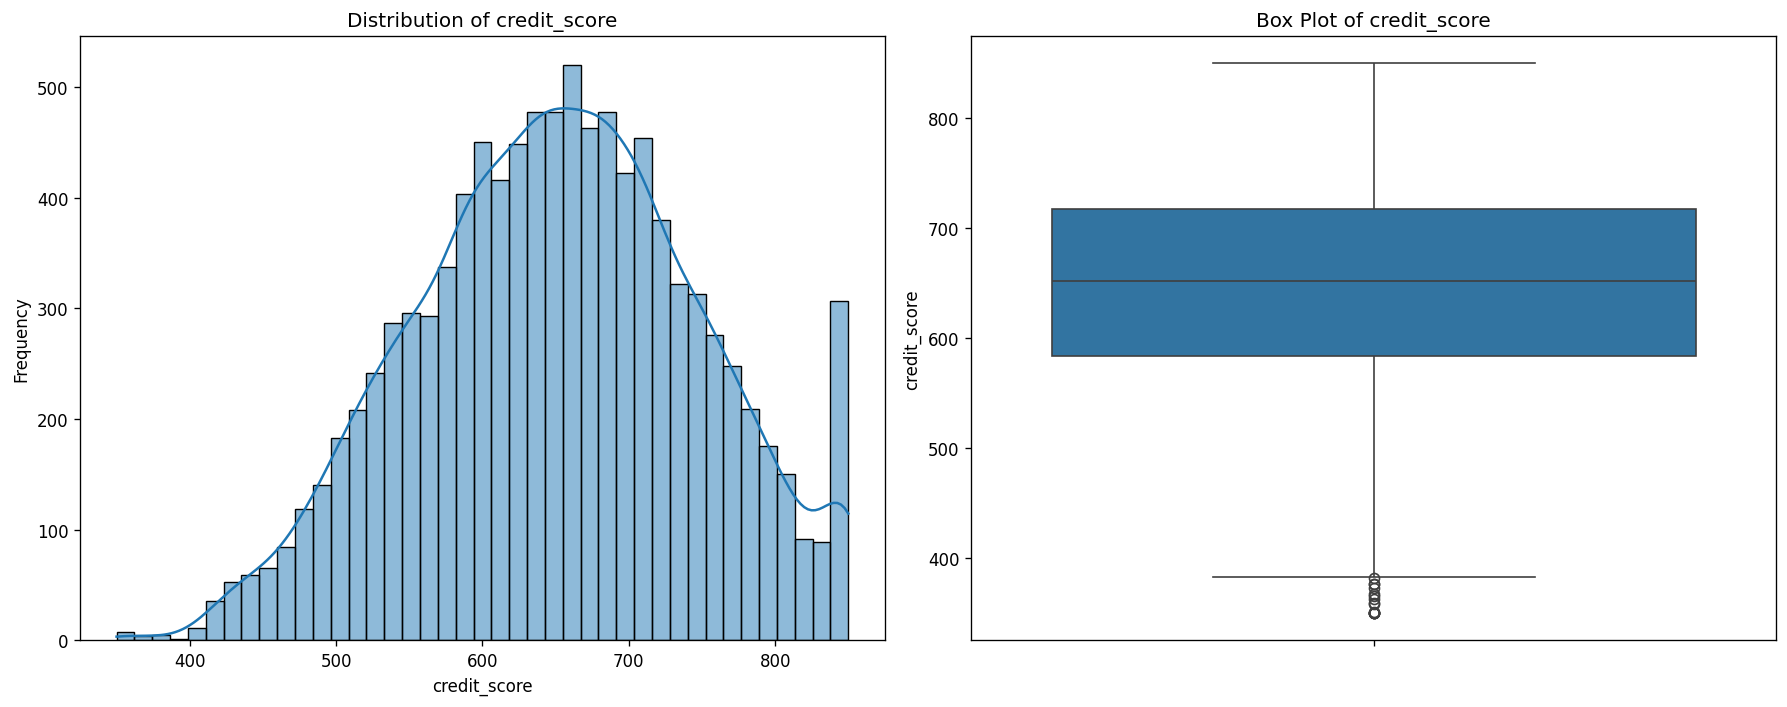

In [ ]:
plt.figure(figsize=(15, 6))

# Histogram for credit_score
plt.subplot(1, 2, 1)
sns.histplot(df['credit_score'], kde=True)
plt.title('Distribution of credit_score')
plt.xlabel('credit_score')
plt.ylabel('Frequency')

# Box plot for CreditScore
plt.subplot(1, 2, 2)
sns.boxplot(y=df['credit_score'])
plt.title('Box Plot of credit_score')
plt.ylabel('credit_score')

plt.tight_layout()
plt.show()


**Từ biểu đồ Histogram:**
* **Phân bố:** Biến `credit_score` có phân bố gần như đối xứng (gần với phân bố chuẩn), tập trung mạnh trong khoảng từ 600 đến 700 điểm.
* **Phạm vi:** Điểm số trải dài từ khoảng 350 đến 850. Việc phân bố tập trung ở mức trung bình cao cho thấy đa số khách hàng của ngân hàng có hồ sơ tín dụng ở mức khá và tốt.

**Từ biểu đồ Box Plot:**
* **Giá trị trung tâm:** Đường trung vị (median) nằm ở khoảng 650 điểm. Hộp (IQR) cho thấy 50% khách hàng có điểm tín dụng nằm trong khoảng từ 584 đến 718.
* **Giá trị ngoại lệ (Outliers):** Xuất hiện một số điểm ngoại lệ ở phía dưới (điểm cực thấp, dưới 400). Đây là nhóm khách hàng có rủi ro tín dụng cao mà ngân hàng cần lưu ý --> thông tin có giá trị phân tích, không loại bỏ.

**Ý nghĩa:**
Nhìn chung, chất lượng tín dụng của tệp khách hàng khá ổn định. Phần lớn KH có điểm tín dụng trung bình–khá (650–720), cho thấy ngân hàng ABC đang phục vụ tệp KH đại trà, không tập trung vào phân khúc cao cấp hay rủi ro cao

### country

Text(0, 0.5, 'Count')

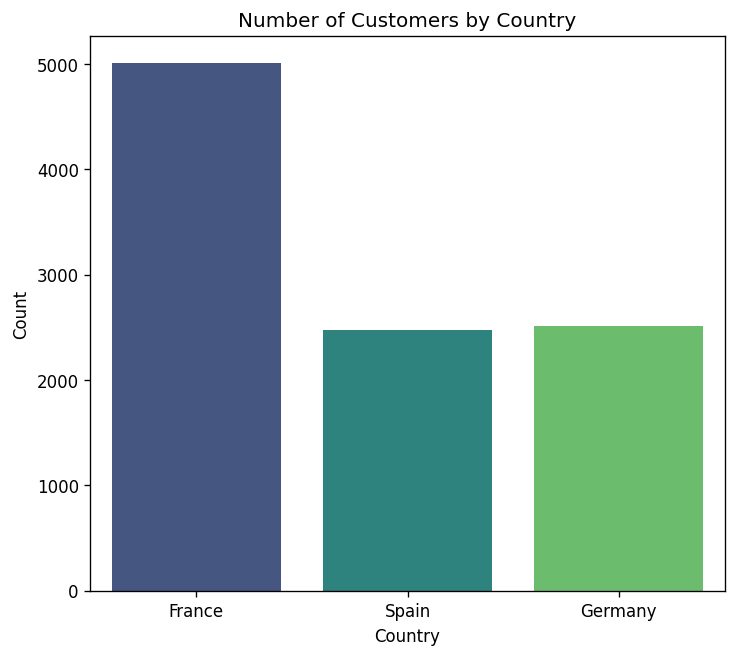

In [ ]:
plt.figure(figsize=(15, 6))

# Count Plot: Customer distribution by country
plt.subplot(1, 2, 1)
sns.countplot(x='country', data=df, palette='viridis')
plt.title('Number of Customers by Country')
plt.xlabel('Country')
plt.ylabel('Count')



- France là thị trường lớn nhất (50%) nhưng Germany và Spain cũng đóng góp ~25% mỗi nước.

→ Ngân hàng có độ phân tán địa lý tương đối tốt, không phụ thuộc quá nhiều vào một thị trường


### gender

Text(0, 0.5, 'Count')

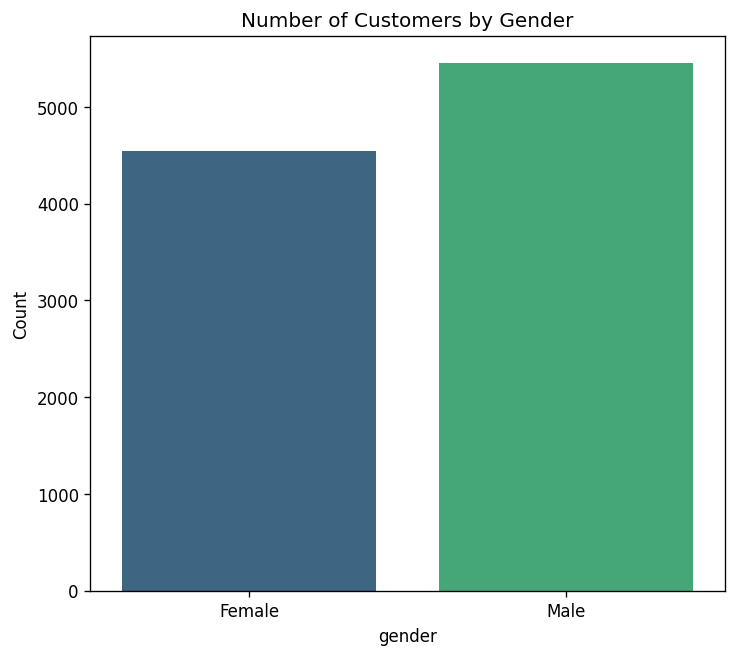

In [ ]:
plt.figure(figsize=(15, 6))

# Count Plot: Customer distribution by country
plt.subplot(1, 2, 1)
sns.countplot(x='gender', data=df, palette='viridis')
plt.title('Number of Customers by Gender')
plt.xlabel('gender')
plt.ylabel('Count')



Nhận xét
- Tỷ lệ Male/Female gần cân bằng
- Ngân hàng không bị lệch về một nhóm giới tính cụ thể

--> Có tính đa dạng trong tệp KH, tạo cơ hội cho sản phẩm nhắm đến từng giới (ví dụ: thẻ tín dụng với quyền lợi khác nhau)


### age

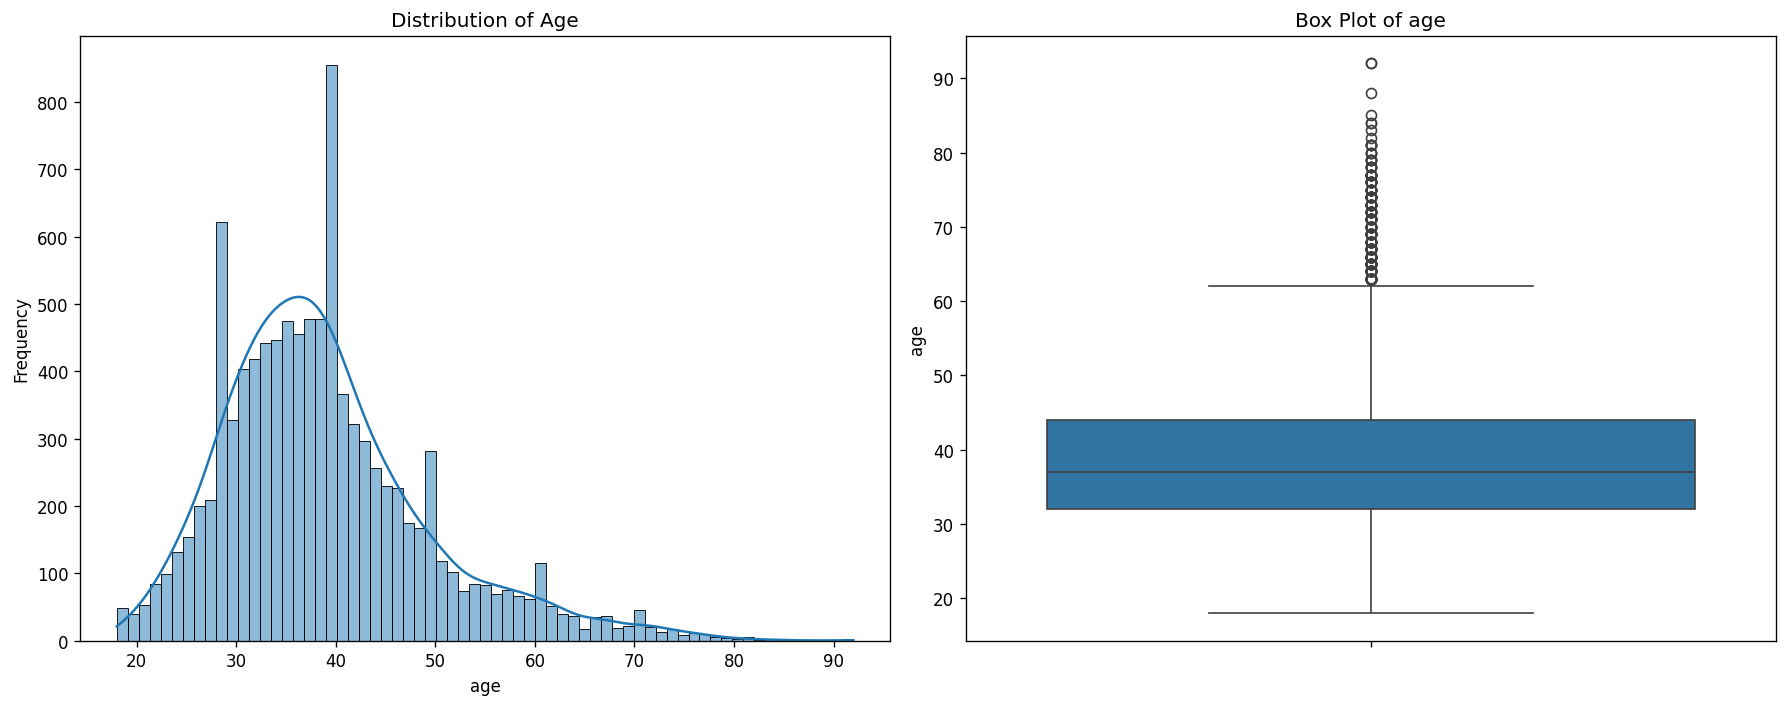

In [ ]:
plt.figure(figsize=(15, 6))

# Histogram for Age
plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('age')
plt.ylabel('Frequency')

# Box plot for Age
plt.subplot(1, 2, 2)
sns.boxplot(y=df['age'])
plt.title('Box Plot of age')
plt.ylabel('age')

plt.tight_layout()
plt.show()

Nhận xét

**Từ biểu đồ Histogram:**
* **Phân bố:** Biến `Age` có phân bố lệch phải (Right-skewed distribution). Phần lớn khách hàng tập trung ở độ tuổi trẻ và trung niên, khoảng từ 30 đến 45 tuổi.
* **Xu hướng:** Số lượng khách hàng giảm dần khi độ tuổi tăng lên, đặc biệt là sau 50 tuổi. Điều này cho thấy tập khách hàng của ngân hàng chủ yếu là những người trong độ tuổi lao động.

**Từ biểu đồ Box Plot:**
* **Giá trị trung vị (Median):** Độ tuổi trung bình của khách hàng nằm ở khoảng 37-38 tuổi.
* **Phạm vi (IQR):** Khoảng 50% khách hàng nằm trong độ tuổi từ khoảng 32 đến 44 tuổi.
* **Giá trị ngoại lệ (Outliers):** Xuất hiện rất nhiều giá trị ngoại lệ ở phía trên (độ tuổi cao, từ khoảng 62 đến trên 90 tuổi). Điều này cho thấy ngân hàng vẫn có một nhóm nhỏ khách hàng là người cao tuổi, mặc dù họ không chiếm đa số --> outliers có giá trị phân tích, không xóa

**Ý nghĩa:**
- Tệp KH chủ lực nằm ở 25–45 tuổi (lực lượng lao động chính) → đây là nhóm có thu nhập ổn định, tiềm năng cross-sell cao.
- Đuôi phải kéo dài đến 70–92 tuổi → ngân hàng vẫn đang giữ được nhóm KH lớn tuổi trung thành, nhưng cũng là nhóm khó thay đổi hành vi nếu dịch vụ không phù hợp.

--> Độ tuổi thường là một yếu tố quan trọng ảnh hưởng đến việc rời bỏ dịch vụ. Người trẻ có thể dễ dàng thay đổi ngân hàng hơn, trong khi nhóm trung niên hoặc cao tuổi có thể có xu hướng trung thành hơn hoặc có hành vi sử dụng dịch vụ tài chính phức tạp hơn. Cần kiểm tra thêm mối quan hệ giữa `Age` và `Exited` ở bước phân tích đa biến.

### tenure

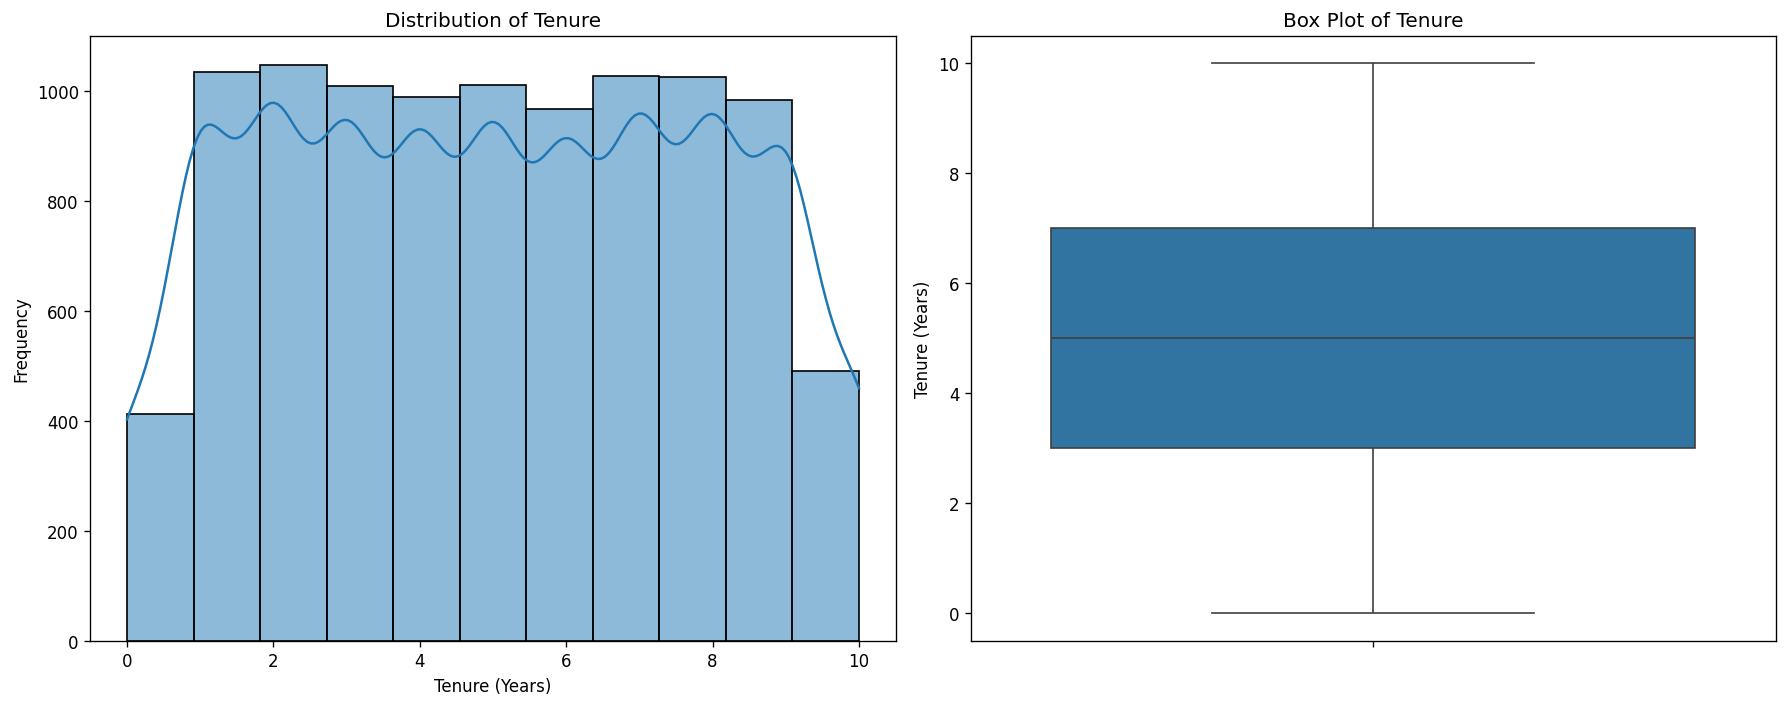

In [ ]:
plt.figure(figsize=(15, 6))

# Histogram for Tenure
plt.subplot(1, 2, 1)
sns.histplot(df['tenure'], bins=11, kde=True)
plt.title('Distribution of Tenure')
plt.xlabel('Tenure (Years)')
plt.ylabel('Frequency')

# Box plot for Tenure
plt.subplot(1, 2, 2)
sns.boxplot(y=df['tenure'])
plt.title('Box Plot of Tenure')
plt.ylabel('Tenure (Years)')

plt.tight_layout()
plt.show()

Nhận xét

**1. Phân bổ:**
* Biến `Tenure` có phân bổ khá đồng đều từ 1 đến 9 năm. Có sự sụt giảm nhẹ ở hai đầu mút (0 năm và 10 năm).
* Điều này cho thấy ngân hàng có một tập khách hàng ổn định với thời gian gắn bó đa dạng, không bị tập trung quá mức vào nhóm khách hàng mới hay nhóm khách hàng quá lâu năm.

**2. Giá trị trung tâm và ngoại lệ:**
* **Trung vị (Median):** Nằm ở khoảng 5 năm.
* **Giá trị ngoại lệ (Outliers):** Không xuất hiện giá trị ngoại lệ

**3. Ý nghĩa:**
- Ngân hàng đang có dòng KH mới đều đặn mỗi năm, không bị phụ thuộc vào một cohort cũ
- Tuy nhiên, không có sự tích lũy rõ ràng ở nhóm tenure cao → có thể ngân hàng chưa tạo được "switching cost(chi phí chuyển đổi)" đủ mạnh để giữ chân KH lâu dài

### balance

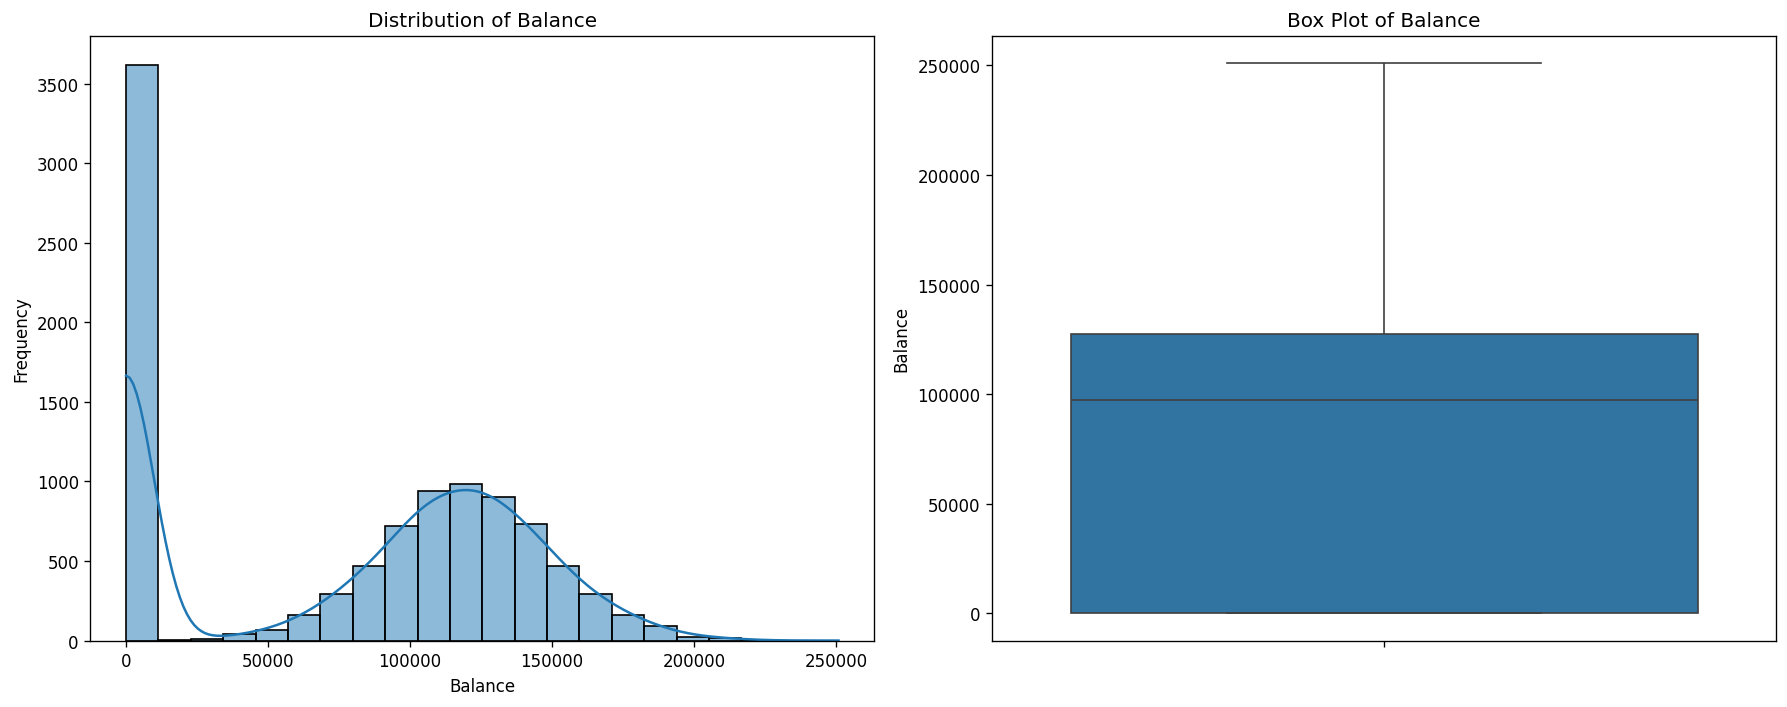

In [ ]:
plt.figure(figsize=(15, 6))

# Histogram for Balance
plt.subplot(1, 2, 1)
sns.histplot(df['balance'], kde=True)
plt.title('Distribution of Balance')
plt.xlabel('Balance')
plt.ylabel('Frequency')

# Box plot for Balance
plt.subplot(1, 2, 2)
sns.boxplot(y=df['balance'])
plt.title('Box Plot of Balance')
plt.ylabel('Balance')

plt.tight_layout()
plt.show()

Nhận xét

* **Nhóm số dư bằng 0:** Có một lượng lớn khách hàng có số dư bằng 0 (cột cao nhất ở phía bên trái histogram). Đây có thể là các tài khoản vãng lai hoặc khách hàng không còn sử dụng tài khoản nhưng chưa đóng.
* **Phân phối:** Ngoài nhóm số dư bằng 0, phần còn lại của dữ liệu có phân phối khá giống chuẩn (Normal Distribution), tập trung chủ yếu quanh mức 100,000 - 125,000.
* **Giá trị ngoại lệ (Outliers):** Biểu đồ Box Plot cho thấy không có giá trị ngoại lệ đáng kể ở phía trên. Điều này cho thấy số dư của khách hàng nằm trong một phạm vi kiểm soát tốt.

 **Ý nghĩa:**
- KH có balance = 0 là nhóm KH "tài khoản ngủ" (dormant), không mang lại nguồn vốn huy động cho ngân hàng -->Cần chương trình kích hoạt lại tài khoản dormant và chính sách lãi suất ưu đãi cho KH duy trì balance cao
- Nhóm có balance cao (150k–250k) là tệp KH giá trị cao cần được ưu tiên giữ chân vì đóng góp lớn vào thanh khoản ngân hàng



### product_number

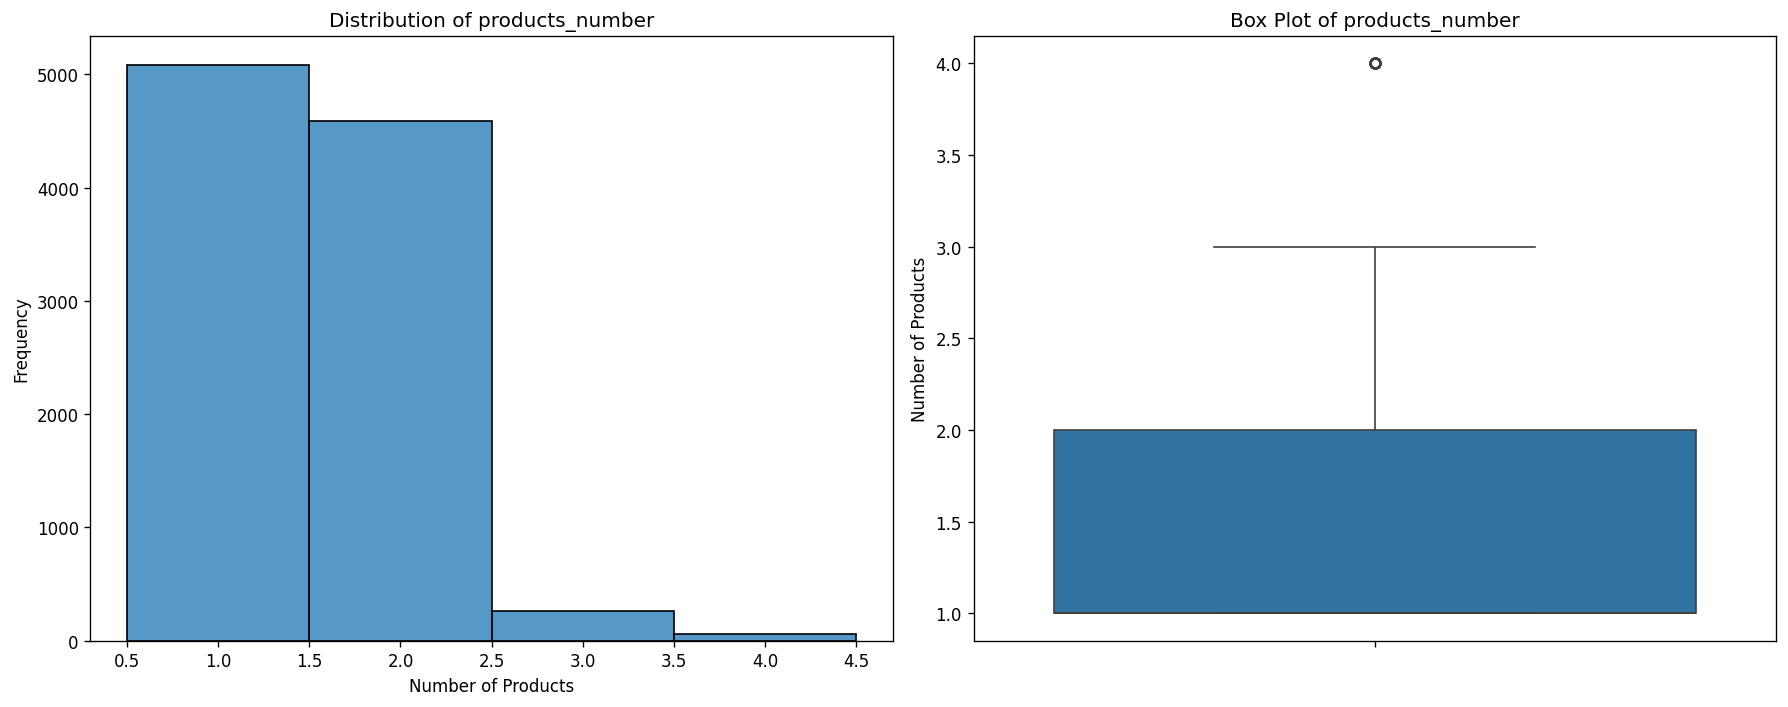

In [ ]:
plt.figure(figsize=(15, 6))

# Histogram for NumOfProducts
plt.subplot(1, 2, 1)
sns.histplot(df['products_number'], discrete=True, kde=False)
plt.title('Distribution of products_number')
plt.xlabel('Number of Products')
plt.ylabel('Frequency')

# Box plot for NumOfProducts
plt.subplot(1, 2, 2)
sns.boxplot(y=df['products_number'])
plt.title('Box Plot of products_number')
plt.ylabel('Number of Products')

plt.tight_layout()
plt.show()

 Nhận xét

**1. Phân bổ:**
* Phần lớn khách hàng sử dụng **1 hoặc 2 sản phẩm**. Đây là nhóm chiếm đa số  trong tập dữ liệu.
* Số lượng khách hàng sử dụng 3 hoặc 4 sản phẩm là rất ít.

**2. Giá trị ngoại lệ:**
* Biểu đồ Box Plot cho thấy các khách hàng sử dụng 4 sản phẩm có thể được coi là giá trị ngoại lệ (outliers) do số lượng quá ít so với mặt bằng chung.

**3. Ý nghĩa trong Churn:**
- ~97% KH chỉ dùng 1–2 sản phẩm → mức độ cross-sell còn rất thấp, KH chưa gắn bó sâu với hệ sinh thái ngân hàng
- KH dùng càng nhiều sản phẩm thường càng khó rời bỏ (higher switching cost) → việc phần lớn chỉ dùng 1–2 sản phẩm khiến rào cản rời bỏ rất thấp, cần đẩy mạnh chiến lược cross-sell từ 1 → 2 sản phẩm là ưu tiên hàng đầu

### credit_card

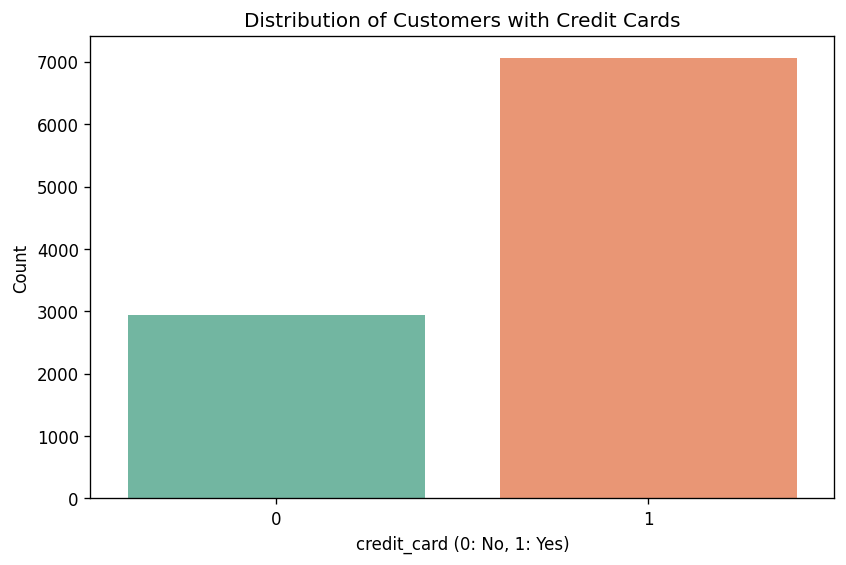

In [ ]:
# Biểu đồ cho HasCrCard (Có thẻ tín dụng hay không)

plt.figure(figsize=(8, 5))
sns.countplot(x='credit_card', data=df, palette='Set2')
plt.title('Distribution of Customers with Credit Cards')
plt.xlabel('credit_card (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()

Nhận xét
* 70.6% KH đã có thẻ tín dụng --> tỷ lệ thâm nhập thẻ khá cao, cho thấy ngân hàng đã cross-sell tốt sản phẩm này
* Còn ~30% chưa có thẻ → là cơ hội upsell còn lại, đặc biệt với nhóm KH có thu nhập và credit score tốt

### active_member

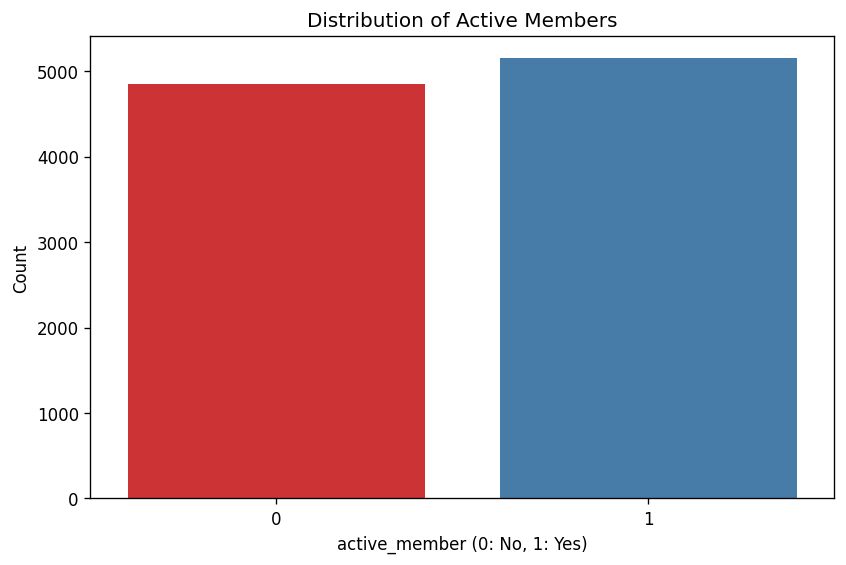

In [ ]:
# Biểu đồ cho IsActiveMember (Khách hàng còn sử dụng dịch vụ hay không)

plt.figure(figsize=(8, 5))
sns.countplot(x='active_member', data=df, palette='Set1')
plt.title('Distribution of Active Members')
plt.xlabel('active_member (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()

 Nhận xét
- Gần 50% KH không hoạt động là tín hiệu rủi ro nghiêm trọng về mặt business
KH không hoạt động (không giao dịch, không dùng dịch vụ) → rất dễ churn và không tạo ra doanh thu

--> Triển khai chương trình re-engagement (email, ưu đãi, thông báo) nhắm vào nhóm này trước khi họ rời bỏ hẳn

###  estimated_salary

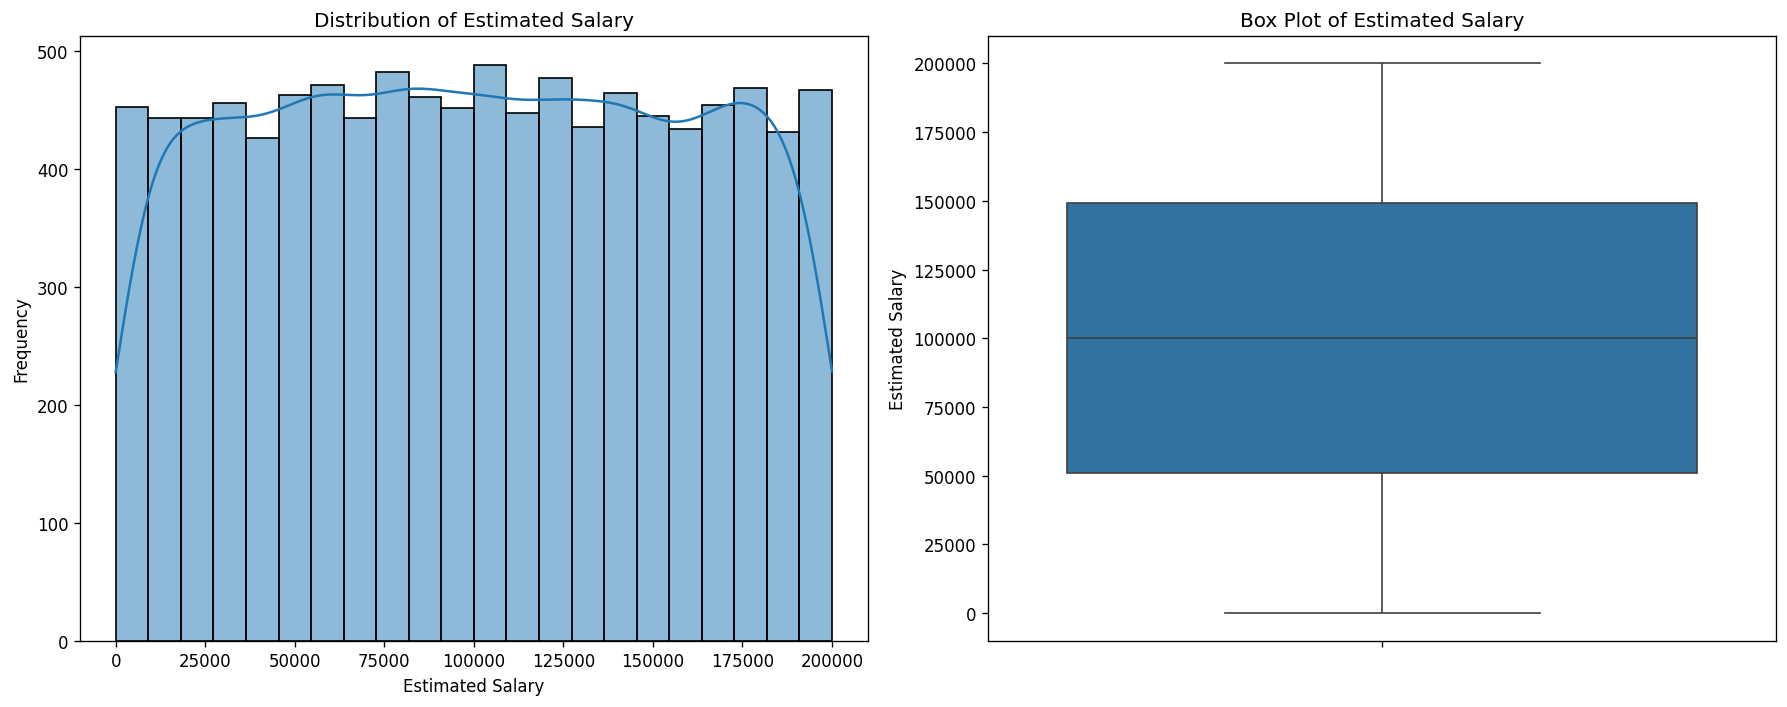

In [ ]:
plt.figure(figsize=(15, 6))

# Histogram for EstimatedSalary
plt.subplot(1, 2, 1)
sns.histplot(df['estimated_salary'], kde=True)
plt.title('Distribution of Estimated Salary')
plt.xlabel('Estimated Salary')
plt.ylabel('Frequency')

# Box plot for EstimatedSalary
plt.subplot(1, 2, 2)
sns.boxplot(y=df['estimated_salary'])
plt.title('Box Plot of Estimated Salary')
plt.ylabel('Estimated Salary')

plt.tight_layout()
plt.show()

 Nhận xét

**Phân bổ:**
* Biến `EstimatedSalary` có phân bổ **đồng đều (Uniform Distribution)**. Điều này có nghĩa là số lượng khách hàng ở các mức thu nhập khác nhau (từ thấp đến cao) là tương đương nhau trong tập dữ liệu.
* Không có sự tập trung đặc biệt vào một khoảng thu nhập cụ thể nào.

**Giá trị trung tâm và ngoại lệ:**
* **Trung vị (Median):** Nằm ở khoảng 100,000.
* **Giá trị ngoại lệ (Outliers):** Biểu đồ Box Plot cho thấy hoàn toàn **không có giá trị ngoại lệ**. Dữ liệu trải dài đều từ mức gần 0 đến 200,000.

**Ý nghĩa:**
- Phân phối hoàn toàn đều từ 0–200k → ngân hàng đang phục vụ toàn bộ phổ thu nhập, từ thấp đến cao
- Không có sự tập trung ở phân khúc thu nhập nào → chiến lược sản phẩm hiện tại mang tính đại trà, chưa có sự cá nhân hóa theo mức thu nhập

--> Có thể phân tầng KH theo thu nhập để thiết kế gói sản phẩm phù hợp.

### churn

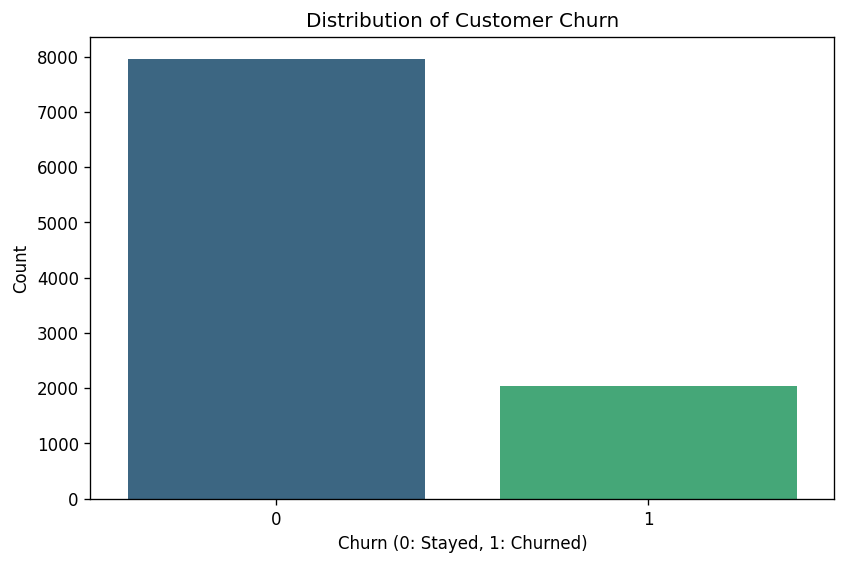

In [ ]:
# Biểu đồ cho biến mục tiêu Exited (Rời bỏ hay ở lại)
plt.figure(figsize=(8, 5))
sns.countplot(x='churn', data=df, palette='viridis')
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn (0: Stayed, 1: Churned)')
plt.ylabel('Count')
plt.show()

Nhận xét
* Dữ liệu cho thấy sự **mất cân bằng (Imbalance)**: Số lượng khách hàng ở lại (0) nhiều hơn đáng kể so với số lượng khách hàng đã rời bỏ (1).

**Ý nghĩa:**
- Tỷ lệ churn 20.4% là mức khá cao trong ngành ngân hàng (benchmark thường là 10–15%)
- Cứ 5 KH thì có 1 người rời bỏ → nếu không có hành động kịp thời, ngân hàng sẽ mất dần tệp KH chất lượng


### **Các biến cần xử lý**

1. Bỏ cột `customer_id`: chỉ là ID định danh, không mang thông tin dự đoán, giữ lại sẽ gây nhiễu.

2. Encoding biến phân loại: `country` dùng One-Hot (3 giá trị, không có thứ tự), `gender` dùng Label Encoding 0/1 (nhị phân).

3. Scaling để giảm chênh lệch về giá trị của các biến numerical

4. Xử lý class imbalance: tỷ lệ 80/20 cần được xử lý (xử lý bằng SMOTE - oversampling dữ liệu minority)







## Bivariate Analysis

### credit_card vs churn



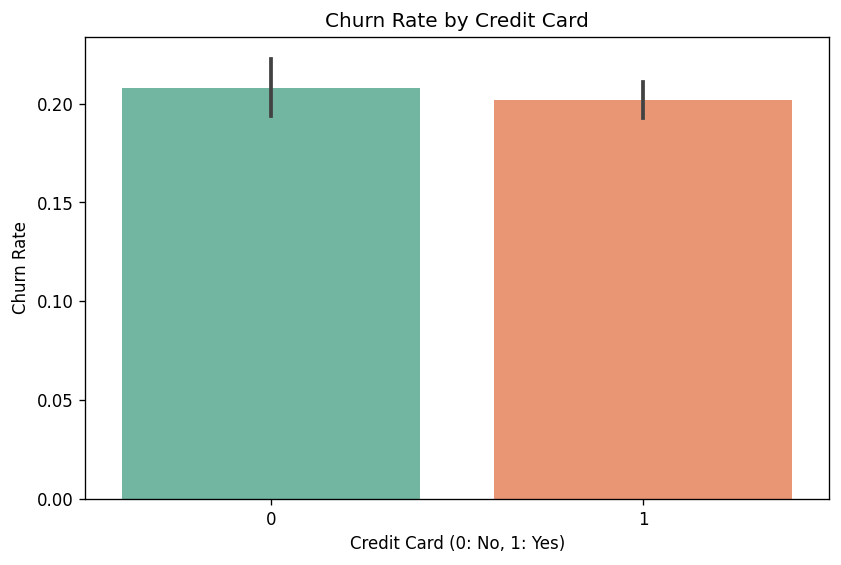

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x='credit_card', y='churn', data=df, palette='Set2')
plt.title('Churn Rate by Credit Card')
plt.xlabel('Credit Card (0: No, 1: Yes)')
plt.ylabel('Churn Rate')
plt.show()

Nhận xét về biến credit_card và churn

**1. Mối quan hệ với tỷ lệ rời bỏ (churn):**
*   Việc sở hữu thẻ tín dụng (`credit_card = 1`) hoặc không sở hữu thẻ tín dụng (`credit_card = 0`) không có sự khác biệt đáng kể về tỷ lệ rời bỏ (`churn`). Cả hai nhóm đều có tỷ lệ rời bỏ tương đối gần nhau, khoảng từ 20-22%.

**2. Ý nghĩa:**
*   Điều này cho thấy `credit_card` có thể không phải là một yếu tố dự đoán mạnh mẽ về việc khách hàng có rời bỏ ngân hàng hay không. Sự hiện diện hay vắng mặt của thẻ tín dụng dường như không ảnh hưởng lớn đến quyết định rời đi của khách hàng.


### active_member vs churn


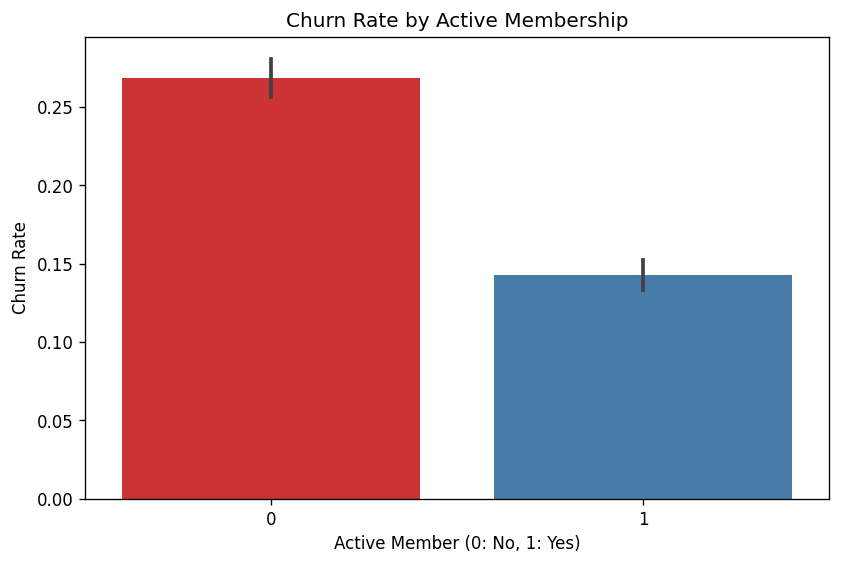

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x='active_member', y='churn', data=df, palette='Set1')
plt.title('Churn Rate by Active Membership')
plt.xlabel('Active Member (0: No, 1: Yes)')
plt.ylabel('Churn Rate')

plt.show()

Nhận xét về biến active_member và churn

**1. Mối quan hệ với tỷ lệ rời bỏ (churn):**
*   Biểu đồ cho thấy có sự khác biệt rõ rệt về tỷ lệ rời bỏ giữa thành viên tích cực và không tích cực.
*   Khách hàng **không tích cực (`active_member = 0`)** có tỷ lệ rời bỏ **cao hơn đáng kể** (trên 25%) so với khách hàng **tích cực (`active_member = 1`)** (tỷ lệ rời bỏ chỉ khoảng 14-15%).

**2. Ý nghĩa:**
*  Khách hàng không còn hoạt động là nhóm có nguy cơ rời bỏ cao nhất.
*   Ngân hàng cần tập trung vào việc **giữ chân và tái kích hoạt** những khách hàng không hoạt động để giảm tỷ lệ churn tổng thể.
*   Các chiến dịch marketing, ưu đãi hoặc liên hệ cá nhân hóa có thể hiệu quả cho nhóm khách hàng không tích cực để khuyến khích họ quay lại sử dụng dịch vụ.

### product_number vs churn



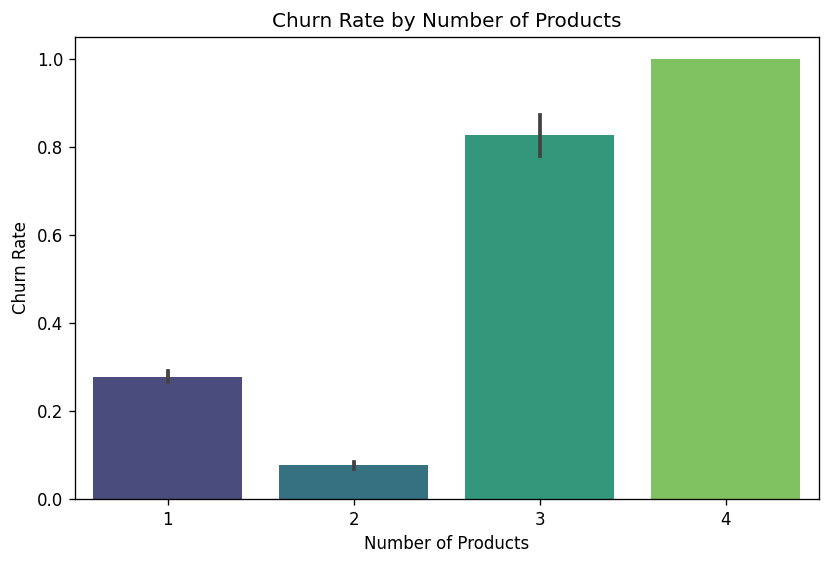

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x='products_number', y='churn', data=df, palette='viridis')
plt.title('Churn Rate by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate')
plt.show()

 Nhận xét về biến product_number và churn

**1. Mối quan hệ với tỷ lệ rời bỏ (churn):**
*   **Khách hàng sử dụng 1 sản phẩm:** Có tỷ lệ rời bỏ tương đối thấp (dưới 30%).
*   **Khách hàng sử dụng 2 sản phẩm:** Có tỷ lệ rời bỏ thấp nhất trong tất cả các nhóm (dưới 10%). Điều này cho thấy đây là nhóm khách hàng có sự gắn kết cao nhất với ngân hàng.
*   **Khách hàng sử dụng 3 sản phẩm:** Có tỷ lệ rời bỏ cực kỳ cao, gần như 100%. Đây là một nhóm khách hàng có nguy cơ rời bỏ dịch vụ rất cao.
*   **Khách hàng sử dụng 4 sản phẩm:** Cũng có tỷ lệ rời bỏ rất cao, mặc dù số lượng khách hàng ở nhóm này là rất ít (như đã nhận xét ở phần Univariate Analysis).

**2. Ý nghĩa:**
*   Ngân hàng cần đặc biệt chú ý đến nhóm khách hàng sử dụng **3 hoặc 4 sản phẩm** vì họ có khả năng rời bỏ gần như chắc chắn. Điều này có thể chỉ ra một vấn đề sâu sắc hơn: có thể những khách hàng này đang gặp khó khăn với các sản phẩm hiện có, hoặc đang tìm kiếm các giải pháp tốt hơn từ đối thủ cạnh tranh.
*   Nhóm khách hàng sử dụng **2 sản phẩm** là nhóm ổn định nhất và cần được duy trì sự hài lòng. Nhóm này có thể là mục tiêu để cross-sell thêm các sản phẩm khác một cách cẩn trọng để tăng thêm sự gắn kết.
*   Nhóm khách hàng chỉ sử dụng **1 sản phẩm** cũng có nguy cơ rời bỏ cao hơn nhóm 2 sản phẩm, cho thấy ngân hàng có thể cần khuyến khích họ sử dụng thêm sản phẩm thứ hai để tăng cường sự gắn kết.

### credit_score vs churn



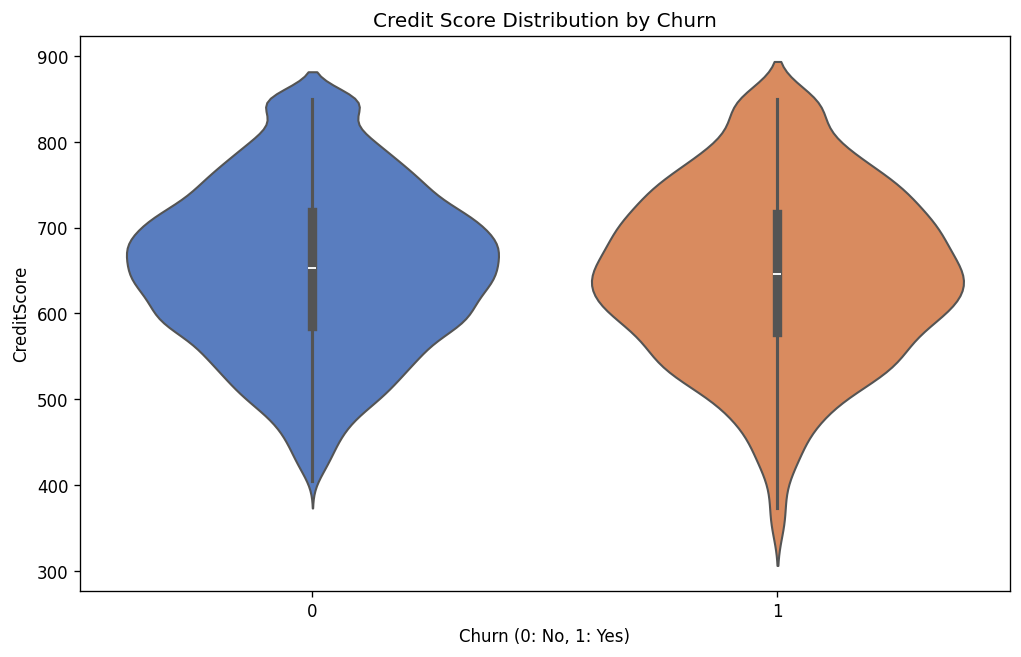

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='churn', y='credit_score', data=df, palette='muted')
plt.title('Credit Score Distribution by Churn')
plt.xlabel('Churn (0: No, 1: Yes)')
plt.ylabel('CreditScore')
plt.show()


Nhận xét về biến credit_score và churn

*   **Phân bố chung:** Cả hai nhóm khách hàng (đã rời bỏ - churn=1 và chưa rời bỏ - churn=0) đều có phân bố điểm tín dụng tập trung chủ yếu trong khoảng 600-750. Điều này cho thấy không có sự khác biệt rõ rệt về điểm tín dụng trung bình giữa hai nhóm.
*   **Điểm tín dụng thấp:** Nhóm khách hàng đã rời bỏ (churn=1) tập trung nhiều hơn ở các điểm tín dụng thấp hơn (dưới 400), mặc dù phạm vi phân bố tổng thể của họ cũng tương tự như nhóm không rời bỏ.
*   **Điểm tín dụng cao:** Tương tự, nhóm khách hàng không rời bỏ (churn=0) cũng có khách hàng với điểm tín dụng rất cao (trên 800), nhưng điều này cũng đúng với nhóm đã rời bỏ.

**Kết luận:**

 Sự phân bố điểm tín dụng của khách hàng đã rời bỏ và chưa rời bỏ khá giống nhau --> Khách hàng có điểm tín dụng tốt hay kém đều có thể rời bỏ hoặc ở lại dịch vụ, và điểm tín dụng đơn lẻ không phải là động lực chính của việc churn.

### age vs churn

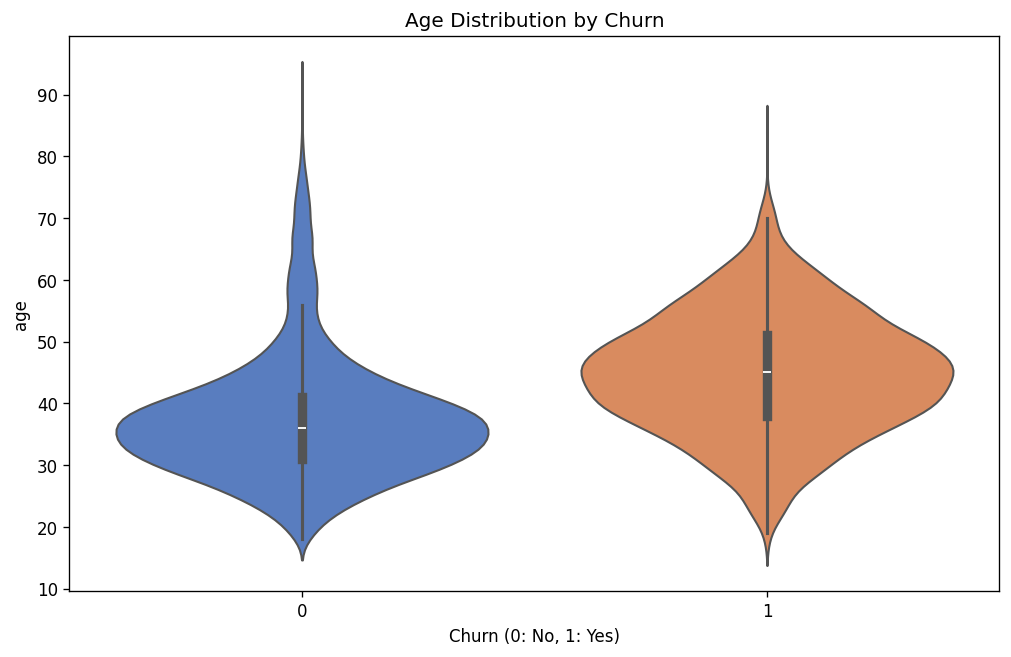

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='churn', y='age', data=df, palette='muted')
plt.title('Age Distribution by Churn')
plt.xlabel('Churn (0: No, 1: Yes)')
plt.ylabel('age')
plt.show()

- Nhóm 40–60 tuổi là "vùng đỏ" cần bảo vệ nhất. Đây không phải ngẫu nhiên — nhóm tuổi này thường đang ở đỉnh thu nhập, có tích lũy tài sản, và bắt đầu quan tâm nghiêm túc hơn đến lãi suất, phí dịch vụ, và chất lượng tư vấn tài chính. Họ có đủ hiểu biết tài chính để so sánh và đủ động lực để chuyển đổi nếu tìm được điều kiện tốt hơn.
- KH trẻ dưới 30 tuổi ít churn không có nghĩa là trung thành. Họ ít rời bỏ có thể vì chưa có đủ tài sản để được ngân hàng khác chào mời, hoặc đơn giản là chưa có nhu cầu phức tạp. Khi họ bước vào ngưỡng 35–40, nguy cơ churn sẽ tăng lên nếu ngân hàng không xây dựng được mối quan hệ sâu từ trước.

### balance vs churn




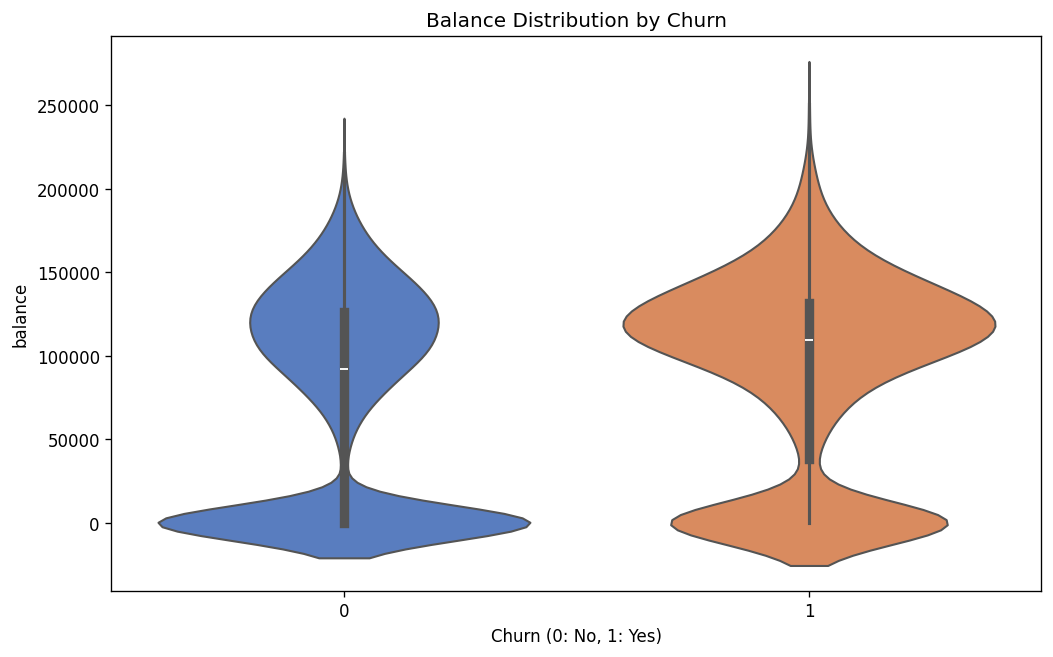

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='churn', y='balance', data=df, palette='muted')
plt.title('Balance Distribution by Churn')
plt.xlabel('Churn (0: No, 1: Yes)')
plt.ylabel('balance')
plt.show()

- KH có balance cao lại churn nhiều hơn KH balance thấp --> có thể do nhóm balance cao có nhiều lựa chọn tài chính hơn, được các ngân hàng đối thủ chào mời lãi suất tốt hơn, và có đủ động lực để chuyển đổi.
- Trong khi đó KH balance = 0 dù "không hoạt động" nhưng cũng không có lý do cụ thể để rời bỏ.

### estimated_salary vs churn


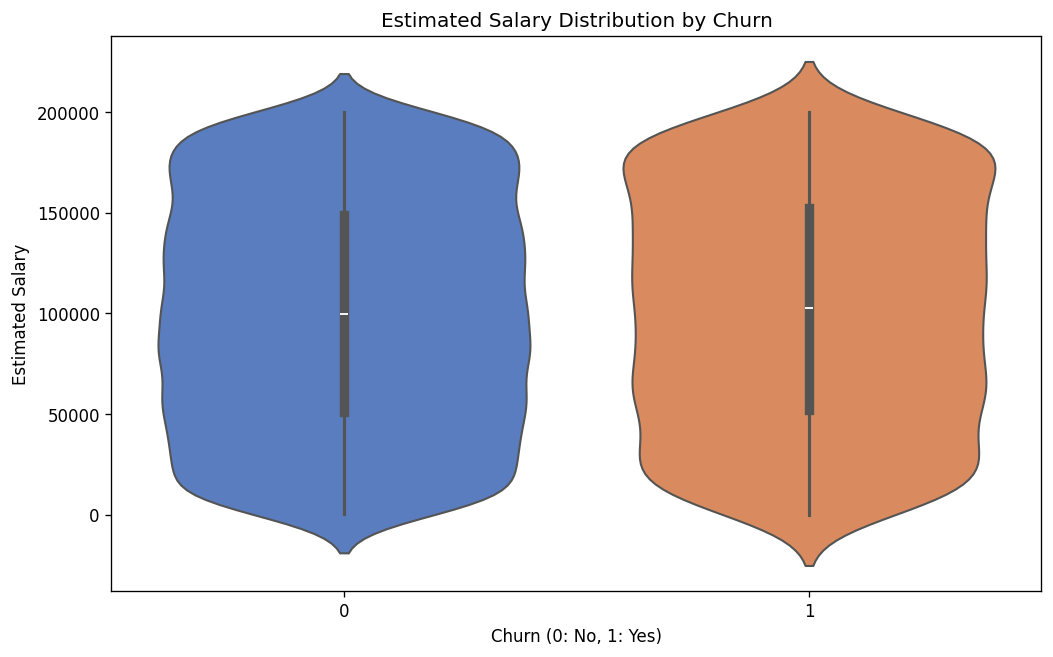

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='churn', y='estimated_salary', data=df, palette='muted')
plt.title('Estimated Salary Distribution by Churn')
plt.xlabel('Churn (0: No, 1: Yes)')
plt.ylabel('Estimated Salary')
plt.show()

Nhận xét về biến estimated_salary và churn

*   **Phân bố:** Biểu đồ cho thấy rằng `estimated_salary` có phân bố tương đối đồng đều cho cả hai nhóm khách hàng (đã rời bỏ - churn=1 và chưa rời bỏ - churn=0). Đây là một đặc điểm nhất quán với nhận xét trong phân tích đơn biến của `estimated_salary`.
*   **Giá trị trung vị và Tứ phân vị:** Các đường trung vị và các hộp trong biểu đồ violin cho thấy rằng không có sự khác biệt đáng kể về mức lương ước tính trung bình hoặc phạm vi giữa khách hàng rời bỏ và không rời bỏ. Các phân vị (25%, 50%, 75%) của `estimated_salary` cho cả hai nhóm đều nằm trong khoảng tương tự nhau.
*   **Hình dạng phân bố:** Hình dạng của biểu đồ violin khá tương tự cho cả hai nhóm, không có sự tập trung rõ rệt ở bất kỳ khoảng lương nào cho nhóm đã rời bỏ so với nhóm không rời bỏ, hoặc ngược lại.

--> Mức lương ước tính của một khách hàng không cung cấp nhiều thông tin để phân biệt liệu họ có khả năng rời bỏ dịch vụ ngân hàng hay không. Khách hàng ở mọi mức thu nhập ước tính đều có khả năng tương đương trong việc rời bỏ hoặc ở lại. Do đó, ngân hàng nên tập trung vào các yếu tố khác có mối quan hệ mạnh mẽ hơn với hành vi churn (ví dụ: `age`, `active_member`, `produc_number`,...)


### gender vs churn


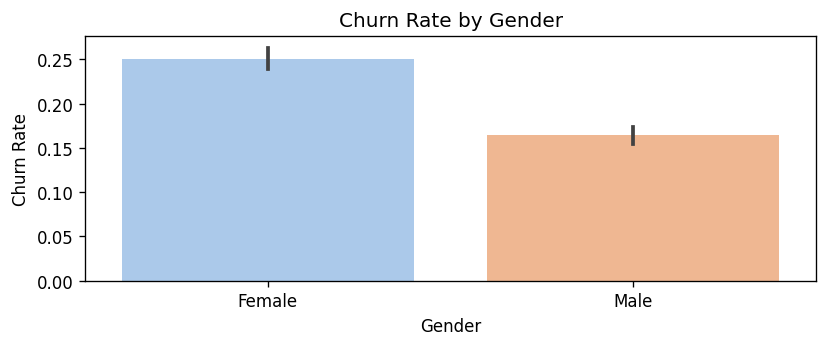

In [ ]:
# Bar Plot: Tỷ lệ rời bỏ theo giới tính
sns.barplot(x='gender', y='churn', data=df, palette='pastel')
plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate')
plt.tight_layout()
plt.show()

**1. Về hành vi rời bỏ (churn):**
* Có sự khác biệt đáng kể về tỷ lệ rời bỏ: **Nữ giới** có tỷ lệ rời bỏ cao hơn so với Nam giới (khoảng 25% so với 16%).

**2. Ý nghĩa:**
* Giới tính là một đặc trưng quan trọng trong việc dự báo Churn. Phụ nữ trong tập dữ liệu này có xu hướng ngừng sử dụng dịch vụ cao hơn, ngân hàng có thể cần các chương trình chăm sóc khách hàng đặc thù hơn cho nhóm đối tượng này.

### country vs churn


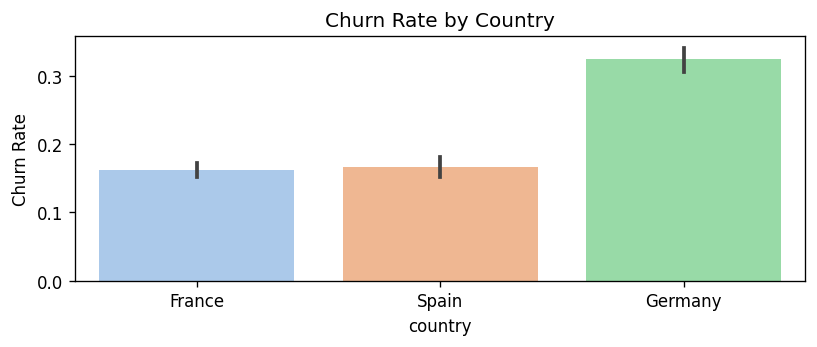

In [ ]:
#  Bar Plot: Tỷ lệ rời bỏ (Exited) theo quốc gia
sns.barplot(x='country', y='churn', data=df, palette='pastel')
plt.title('Churn Rate by Country')
plt.xlabel('country')
plt.ylabel('Churn Rate')
plt.tight_layout()
plt.show()



**1. Về hành vi rời bỏ (Churn):**
* Có sự khác biệt rất lớn về tỷ lệ rời bỏ giữa các quốc gia.
* Khách hàng tại **Đức** có tỷ lệ rời bỏ cao bất thường (khoảng trên 30%), trong khi ở Pháp và Tây Ban Nha tỷ lệ này chỉ dao động quanh mức 16-17%.

**2. Ý nghĩa:**
* Biến `country` là một trong những đặc trưng (feature) có khả năng phân loại mạnh nhất.
* Ngân hàng cần tìm hiểu sâu hơn lý do tại sao khách hàng ở Đức lại rời bỏ dịch vụ nhiều hơn (có thể do dịch vụ đối thủ cạnh tranh tốt hơn, chính sách phí, hoặc sự khác biệt về văn hóa tiêu dùng).

### Bivariate Heatmap

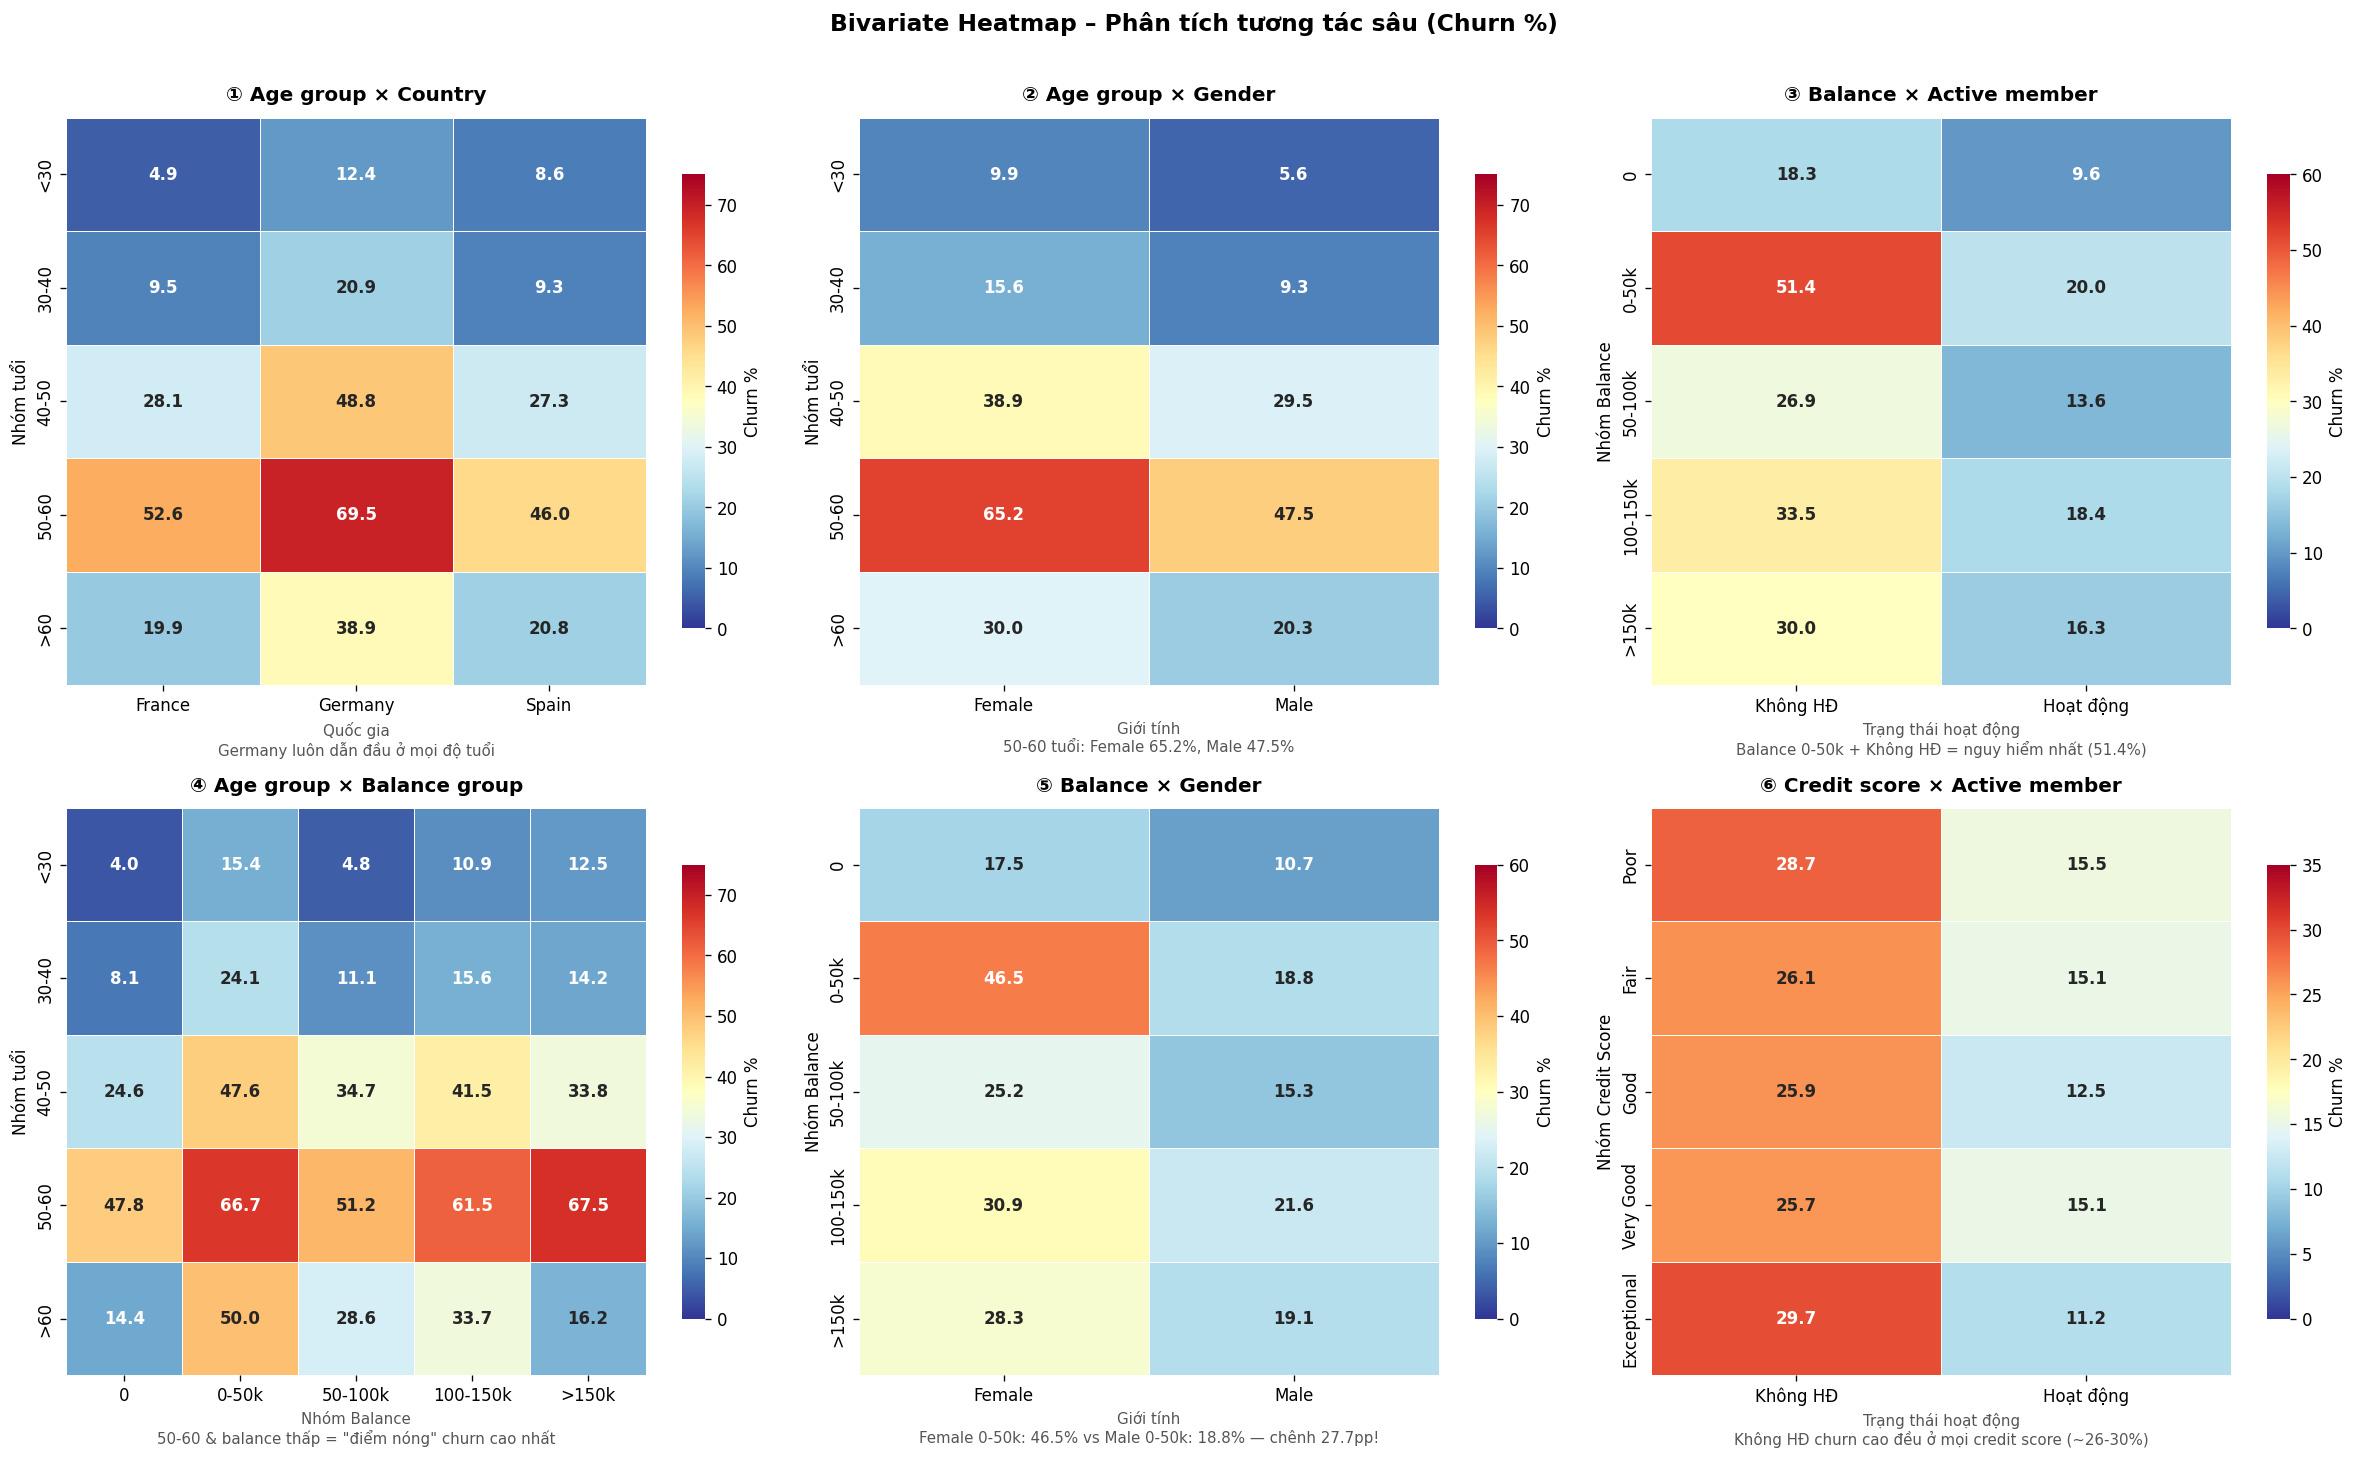

In [ ]:
df2 = df.copy()
df2['age_group'] = pd.cut(df2['age'],
                           bins=[0, 30, 40, 50, 60, 100],
                           labels=['<30', '30-40', '40-50', '50-60', '>60'])

df2['balance_group'] = pd.cut(df2['balance'],
                               bins=[-1, 0, 50000, 100000, 150000, 300000],
                               labels=['0', '0-50k', '50-100k', '100-150k', '>150k'])

df2['score_group'] = pd.cut(df2['credit_score'],
                             bins=[0, 580, 670, 740, 800, 860],
                             labels=['Poor', 'Fair', 'Good', 'Very Good', 'Exceptional'])

# ── Hàm vẽ heatmap dùng chung ────────────────────────────────
def draw_heatmap(ax, data, title, xlabel, ylabel, vmin=0, vmax=60, note=''):
    mask = data.isna()
    sns.heatmap(data, ax=ax, annot=True, fmt='.1f', cmap='RdYlBu_r',
                linewidths=0.6, linecolor='white',
                vmin=vmin, vmax=vmax, mask=mask,
                cbar_kws={'label': 'Churn %', 'shrink': 0.8},
                annot_kws={'size': 10, 'weight': 'bold'})
    # Tô ô NaN màu xám + label
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if pd.isna(data.iloc[i, j]):
                ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color='#DDDDDD'))
                ax.text(j + 0.5, i + 0.5, 'N/A', ha='center', va='center',
                        fontsize=9, color='#888')
    ax.set_title(title, fontweight='bold', fontsize=12, pad=10)
    ax.set_ylabel(ylabel, fontsize=10)
    if note:
        ax.set_xlabel(f'{xlabel}\n{note}', fontsize=9, color='#555')
    else:
        ax.set_xlabel(xlabel, fontsize=10)

# ── Vẽ 6 heatmaps ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# ① Age group × Country
p1 = df2.groupby(['age_group', 'country'], observed=True)['churn'].mean().unstack() * 100
draw_heatmap(axes[0, 0], p1,
             '① Age group × Country',
             'Quốc gia', 'Nhóm tuổi', vmax=75,
             note='Germany luôn dẫn đầu ở mọi độ tuổi')

# ② Age group × Gender
p2 = df2.groupby(['age_group', 'gender'], observed=True)['churn'].mean().unstack() * 100
draw_heatmap(axes[0, 1], p2,
             '② Age group × Gender',
             'Giới tính', 'Nhóm tuổi', vmax=75,
             note='50-60 tuổi: Female 65.2%, Male 47.5%')

# ③ Balance × Active member
p3 = df2.groupby(['balance_group', 'active_member'], observed=True)['churn'].mean().unstack() * 100
p3.columns = ['Không HĐ', 'Hoạt động']
draw_heatmap(axes[0, 2], p3,
             '③ Balance × Active member',
             'Trạng thái hoạt động', 'Nhóm Balance', vmax=60,
             note='Balance 0-50k + Không HĐ = nguy hiểm nhất (51.4%)')

# ④ Age group × Balance group
p4 = df2.groupby(['age_group', 'balance_group'], observed=True)['churn'].mean().unstack() * 100
draw_heatmap(axes[1, 0], p4,
             '④ Age group × Balance group',
             'Nhóm Balance', 'Nhóm tuổi', vmax=75,
             note='50-60 & balance thấp = "điểm nóng" churn cao nhất')

# ⑤ Balance × Gender
p5 = df2.groupby(['balance_group', 'gender'], observed=True)['churn'].mean().unstack() * 100
draw_heatmap(axes[1, 1], p5,
             '⑤ Balance × Gender',
             'Giới tính', 'Nhóm Balance', vmax=60,
             note='Female 0-50k: 46.5% vs Male 0-50k: 18.8% — chênh 27.7pp!')

# ⑥ Credit score × Active member
p6 = df2.groupby(['score_group', 'active_member'], observed=True)['churn'].mean().unstack() * 100
p6.columns = ['Không HĐ', 'Hoạt động']
draw_heatmap(axes[1, 2], p6,
             '⑥ Credit score × Active member',
             'Trạng thái hoạt động', 'Nhóm Credit Score', vmax=35,
             note='Không HĐ churn cao đều ở mọi credit score (~26-30%)')

plt.suptitle('Bivariate Heatmap – Phân tích tương tác sâu (Churn %)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Features Correlation

In [ ]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

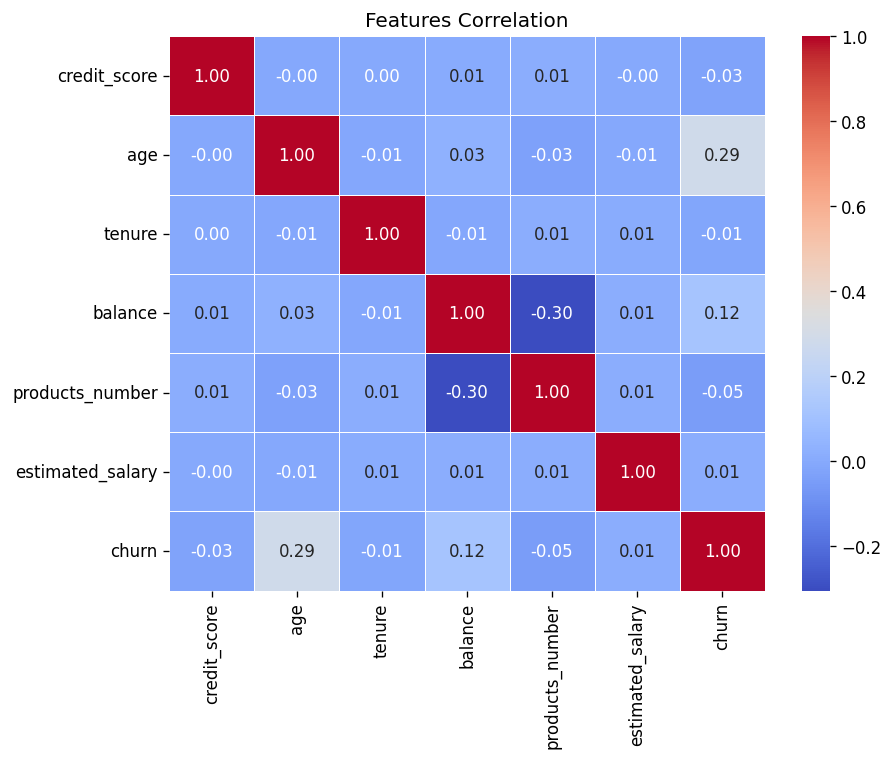

In [ ]:
# Chọn các cột số để tính ma trận tương quan
numerical_cols = ['credit_score', 'age', 'tenure','balance', 'products_number','estimated_salary', 'churn']

# Tính ma trận tương quan
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Features Correlation')
plt.show()

Nhận xét về Ma trận tương quan
1. Mối quan hệ với biến mục tiêu churn (Rời bỏ):
- `age`: Có mối tương quan dương đáng kể nhất với churn (khoảng 0.28). Điều này cho thấy khách hàng lớn tuổi hơn có xu hướng rời bỏ dịch vụ nhiều hơn.
- `active_member`: Có mối tương quan âm mạnh với churn (khoảng -0.16). Khách hàng không còn hoạt động tích cực có khả năng rời bỏ cao hơn.
- `balance`: Có mối tương quan dương nhẹ với churn (khoảng 0.12). Khách hàng có số dư cao hơn có một chút xu hướng rời bỏ.
- `credit_score`, `tenure`, `credit_card`, `estimated_salary`, `products_number`: Các biến này có mối tương quan rất thấp (gần như bằng 0) với churn, cho thấy không có mối quan hệ tuyến tính mạnh mẽ với việc rời bỏ.
2. Mối quan hệ giữa các biến độc lập:
- balance và products_number: Có mối tương quan âm vừa phải (khoảng -0.30). Điều này có thể ngụ ý rằng khách hàng có số dư cao hơn có xu hướng sử dụng ít sản phẩm hơn, và ngược lại.
- Các cặp biến còn lại: Hầu hết các cặp biến độc lập khác đều có mối tương quan rất yếu

## **Kết luận chân dung khách hàng rời bỏ**
- Chân dung KH rời bỏ điển hình là: phụ nữ trung niên 40–60 tuổi, đang sinh sống tại Germany, có số dư tài khoản trung bình–cao nhưng không còn tích cực sử dụng dịch vụ, và chỉ gắn bó với 1 sản phẩm duy nhất. Đây là người đang ở đỉnh tích lũy tài chính, có hiểu biết để so sánh và đủ động lực để chuyển sang ngân hàng cạnh tranh nếu không được giữ chân.
- Ba tín hiệu cảnh báo sớm nhất mà ngân hàng cần theo dõi theo thời gian thực là: KH chuyển từ active sang inactive, KH giảm balance xuống vùng 0–50k, và KH đang dùng 2 sản phẩm không có dấu hiệu mở thêm sản phẩm thứ 3.
Nghịch lý balance cần được truyền thông nội bộ rõ ràng: KH có balance cao không phải là KH trung thành — họ là KH có nhiều thứ để "mang đi". Chiến lược giữ chân nhóm này cần tập trung vào giá trị dịch vụ và tư vấn cá nhân, không chỉ lãi suất.
- Thị trường Germany cần được điều tra riêng ở cấp chiến lược — tỷ lệ churn gần gấp đôi France và Spain ở mọi nhóm tuổi và giới tính cho thấy đây không phải vấn đề nhân khẩu học mà là vấn đề sản phẩm, dịch vụ, hoặc cạnh tranh cục bộ.

## X, y Selection

In [ ]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

In [ ]:
# Chia features (X) and target (y)
features = ['credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary']
X = df[features]
y = df['churn']

In [ ]:
display(X.head())
display(y.head())

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


,churn
0,1
1,0
2,1
3,0
4,0


## Encoding


In [ ]:
# One-Hot Encoding cho các cột 'Country'
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe_array = ohe.fit_transform(X[["country"]])
ohe_cols = ohe.get_feature_names_out(["country"])
X = pd.concat([
    X.reset_index(drop=True),
    pd.DataFrame(ohe_array, columns=ohe_cols).astype(int)
], axis=1)

In [ ]:
X.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_France,country_Germany,country_Spain
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,France,Female,39,1,0.00,2,0,0,93826.63,1,0,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,1


In [ ]:
# Gender: Label - sử dụng LabelEncoder của scikit-learn
le_gender = LabelEncoder().fit(X['gender'])
X['gender'] = le_gender.transform(X['gender'])
X['gender'] = le_gender.fit_transform(X['gender'])
X.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_France,country_Germany,country_Spain
0,619,France,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,France,0,39,1,0.00,2,0,0,93826.63,1,0,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0,0,1


In [ ]:
# Drop cột Country
X = X.drop('country', axis=1)
X.head()

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_France,country_Germany,country_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


 ## Split train/test dataset

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Kích thước tập huấn luyện X_train:", X_train.shape)
print("Kích thước tập kiểm tra X_test:", X_test.shape)
print("Kích thước tập huấn luyện y_train:", y_train.shape)
print("Kích thước tập kiểm tra y_test:", y_test.shape)

Kích thước tập huấn luyện X_train: (8000, 12)
Kích thước tập kiểm tra X_test: (2000, 12)
Kích thước tập huấn luyện y_train: (8000,)
Kích thước tập kiểm tra y_test: (2000,)


## Xử lý Imbalance

In [ ]:
# Xử lý imbalance: Oversampling
from imblearn.over_sampling import SMOTE

# Instantiate SMOTE
sm = SMOTE(random_state=42)

# Resample the training data
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

print("Class distribution before oversampling (y_train):")
print(y_train.value_counts())
print("\nClass distribution after oversampling (y_train_resampled):")
print(y_train_resampled.value_counts())

Class distribution before oversampling (y_train):
churn
0    6370
1    1630
Name: count, dtype: int64

Class distribution after oversampling (y_train_resampled):
churn
1    6370
0    6370
Name: count, dtype: int64


## Scaling

In [ ]:
# 2. Instantiate StandardScaler
stdscal = StandardScaler()

# 3. Fit stdscal to X_train
stdscal.fit(X_train_resampled)

# 4. Transform X_train and X_test
X_train_stdscal_array = stdscal.transform(X_train_resampled)
X_test_stdscal_array = stdscal.transform(X_test)

# 5. Convert the transformed arrays back into pandas DataFrames
X_train_stdscal = pd.DataFrame(X_train_stdscal_array, columns=X_train_resampled.columns)
X_test_stdscal = pd.DataFrame(X_test_stdscal_array, columns=X_test.columns)

# 6. Display the first five rows of
print("First 5 rows of X_train after StandardScaler Scaling:")
display(X_train_stdscal.head())

print("\nFirst 5 rows of X_test after StandardScaler Scaling:")
display(X_test_stdscal.head())

First 5 rows of X_train after StandardScaler Scaling:


,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_France,country_Germany,country_Spain
0,1.135396,1.173777,1.600783,0.787428,-1.348935,-0.728277,0.776998,-0.765221,1.017874,1.264282,-0.580009,-0.463506
1,0.982531,1.173777,-0.893185,-0.680932,0.327477,-0.728277,0.776998,-0.765221,-0.641256,-0.790963,1.724111,-0.463506
2,1.157234,-0.851950,-0.394392,-1.782201,0.520137,1.037663,0.776998,1.306812,0.286786,-0.790963,1.724111,-0.463506
3,-0.961044,1.173777,-0.394392,0.053248,-1.348935,1.037663,0.776998,-0.765221,-0.309202,1.264282,-0.580009,-0.463506
4,0.469340,1.173777,0.802713,0.420338,0.465561,1.037663,-1.287004,1.306812,0.114377,-0.790963,1.724111,-0.463506



First 5 rows of X_test after StandardScaler Scaling:


,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_France,country_Germany,country_Spain
0,-0.698989,1.173777,-0.494150,0.787428,-1.348935,1.037663,0.776998,-0.765221,-0.114787,1.264282,-0.580009,-0.463506
1,-1.354127,1.173777,-0.793427,-0.313842,0.801790,1.037663,-1.287004,-0.765221,-0.796033,-0.790963,1.724111,-0.463506
2,-1.004720,-0.851950,-0.095115,-0.313842,-1.348935,1.037663,-1.287004,1.306812,0.078943,-0.790963,-0.580009,2.157471
3,-0.109365,1.173777,-0.693668,0.053248,0.939173,1.037663,-1.287004,-0.765221,-1.163027,-0.790963,-0.580009,2.157471
4,-0.098446,-0.851950,-0.693668,-0.680932,-0.071426,-0.728277,0.776998,1.306812,1.175454,-0.790963,-0.580009,2.157471


# Model Training

In [ ]:
# Khởi tạo mô hình Decision Tree
dtc = DecisionTreeClassifier(random_state=42)

# Huấn luyện mô hình
dtc.fit(X_train_stdscal, y_train_resampled)

# Dự đoán trên tập kiểm tra
y_pred_dtc = dtc.predict(X_test_stdscal)

print("Mô hình Decision Tree đã được huấn luyện thành công.")

Mô hình Decision Tree đã được huấn luyện thành công.


In [ ]:
# Khởi tạo mô hình Random Forest
rfc = RandomForestClassifier(random_state=42)

# Huấn luyện mô hình
rfc.fit(X_train_stdscal, y_train_resampled)

# Dự đoán trên tập kiểm tra
y_pred_rfc = rfc.predict(X_test_stdscal)

print("Mô hình Random Forest đã được huấn luyện thành công.")

Mô hình Random Forest đã được huấn luyện thành công.


In [ ]:
# 3. Khởi tạo và huấn luyện mô hình Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train_stdscal, y_train_resampled)

# Dự đoán trên tập kiểm tra
y_pred_lr = lr.predict(X_test_stdscal)

print("Mô hình Logistic Regression đã được huấn luyện thành công.")

Mô hình Logistic Regression đã được huấn luyện thành công.


In [ ]:
# 4. Khởi tạo và huấn luyện mô hình K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_stdscal, y_train_resampled)

# Dự đoán trên tập kiểm tra
y_pred_knn = knn.predict(X_test_stdscal)

print("Mô hình KNN đã được huấn luyện thành công.")

Mô hình KNN đã được huấn luyện thành công.


In [ ]:
# 5. Khởi tạo và huấn luyện mô hình Support Vector Classifier (SVC)
svc = SVC(random_state=42)
svc.fit(X_train_stdscal, y_train_resampled)

# Dự đoán trên tập kiểm tra
y_pred_svc = svc.predict(X_test_stdscal)

print("Mô hình SVC đã được huấn luyện thành công.")

Mô hình SVC đã được huấn luyện thành công.


# Model Evaluation

Đánh giá mô hình Decision Tree:
Accuracy: 0.7645
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.81      0.85      1593
           1       0.44      0.59      0.50       407

    accuracy                           0.76      2000
   macro avg       0.66      0.70      0.67      2000
weighted avg       0.79      0.76      0.78      2000

Confusion Matrix:


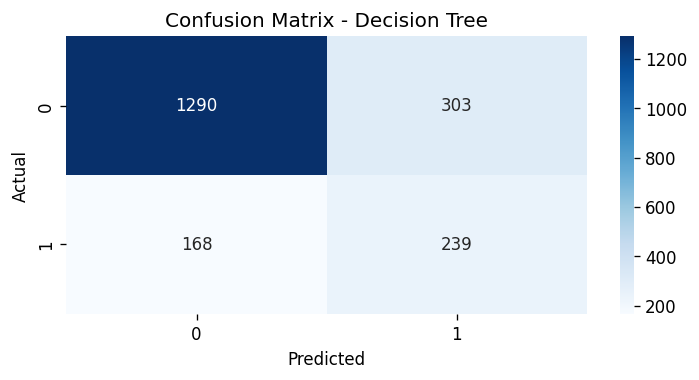

In [ ]:
# Đánh giá mô hình Decision Tree
print("Đánh giá mô hình Decision Tree:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dtc):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_dtc))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_dtc), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Đánh giá mô hình Random Forest:
Accuracy: 0.8395
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1593
           1       0.61      0.60      0.60       407

    accuracy                           0.84      2000
   macro avg       0.75      0.75      0.75      2000
weighted avg       0.84      0.84      0.84      2000

Confusion Matrix:


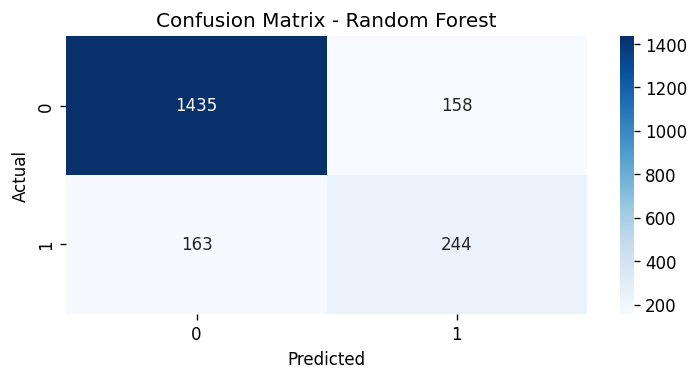

In [ ]:
# Đánh giá mô hình Random Forest
print("\nĐánh giá mô hình Random Forest:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rfc):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rfc))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_rfc), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Đánh giá mô hình Logistic Regression:
Accuracy: 0.7770
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1593
           1       0.45      0.46      0.46       407

    accuracy                           0.78      2000
   macro avg       0.66      0.66      0.66      2000
weighted avg       0.78      0.78      0.78      2000

Confusion Matrix:


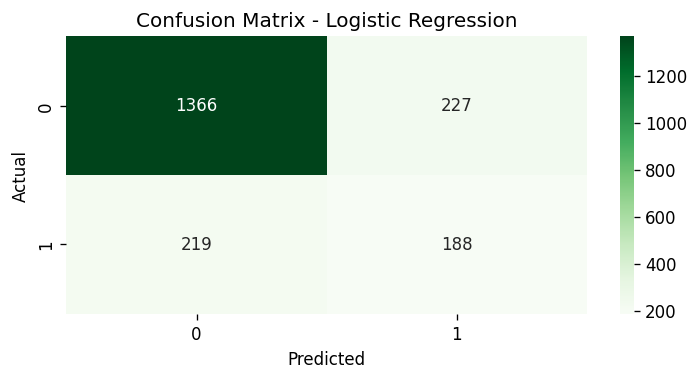

In [ ]:
# Đánh giá mô hình Logistic Regression
print("Đánh giá mô hình Logistic Regression:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Đánh giá mô hình KNN:
Accuracy: 0.8015
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      1593
           1       0.51      0.56      0.53       407

    accuracy                           0.80      2000
   macro avg       0.70      0.71      0.70      2000
weighted avg       0.81      0.80      0.80      2000

Confusion Matrix:


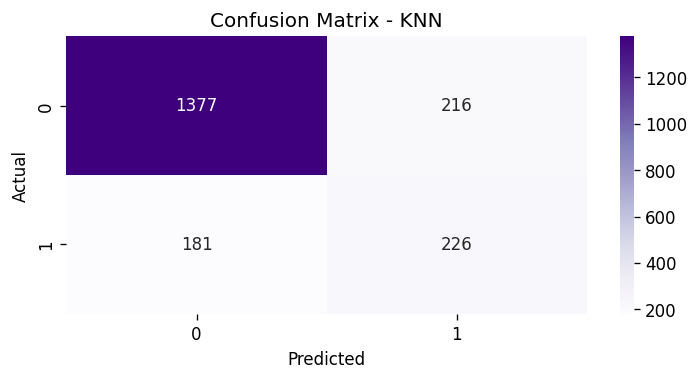

In [ ]:
# Đánh giá mô hình KNN
print("Đánh giá mô hình KNN:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_knn))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Đánh giá mô hình SVC:
Accuracy: 0.8360
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.90      1593
           1       0.60      0.58      0.59       407

    accuracy                           0.84      2000
   macro avg       0.75      0.74      0.74      2000
weighted avg       0.83      0.84      0.84      2000

Confusion Matrix:


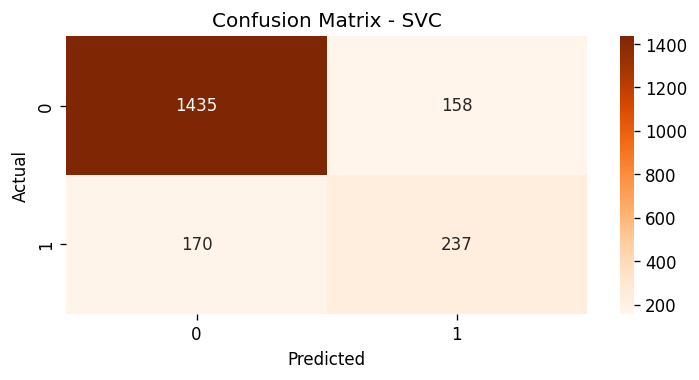

In [ ]:
# Đánh giá mô hình SVC
print("Đánh giá mô hình SVC:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_svc))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_svc), annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - SVC')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Nhận xét**

- Random Forest & SVC cho thấy hiệu suất vượt trội về độ chính xác tổng thể và khả năng phân loại khách hàng rời bỏ dịch vụ (churners).
- Logistic Regression gặp khó khăn với tập dữ liệu này khi có điểm Recall và F1 thấp nhất, nghĩa là nó đã bỏ sót nhiều khách hàng có khả năng rời bỏ dịch vụ.
- Decision Tree có điểm Recall khá tốt (0,59) nhưng lại bị điểm Precision thấp (0,44), dẫn đến nhiều "báo động giả" (dự đoán khách hàng sẽ rời đi trong khi thực tế họ vẫn ở lại).

# Features Importance

             Feature  Importance
2                age    0.235676
4            balance    0.129037
7      active_member    0.120814
8   estimated_salary    0.107011
5    products_number    0.092173
0       credit_score    0.089603
3             tenure    0.054357
9     country_France    0.043937
11     country_Spain    0.042404
1             gender    0.037791
10   country_Germany    0.032711
6        credit_card    0.014485


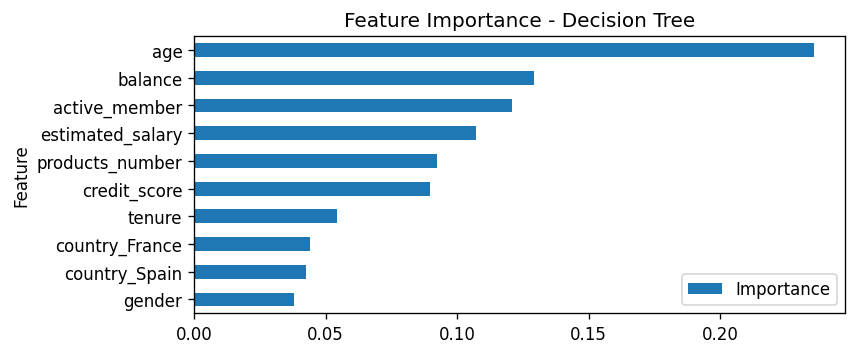

In [ ]:
# Importance of Feature
importances = dtc.feature_importances_
feat_imp = pd.DataFrame({
    "Feature": X_train_stdscal.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)
print(feat_imp)

import matplotlib.pyplot as plt
feat_imp.head(10).plot(
    x="Feature",
    y="Importance",
    kind="barh"
)
plt.gca().invert_yaxis()
plt.title("Feature Importance - Decision Tree")
plt.show()

             Feature  Importance
2                age    0.206888
4            balance    0.111595
8   estimated_salary    0.106564
5    products_number    0.101640
7      active_member    0.101456
0       credit_score    0.096408
9     country_France    0.062837
3             tenure    0.062603
1             gender    0.053048
11     country_Spain    0.050665
10   country_Germany    0.028349
6        credit_card    0.017948


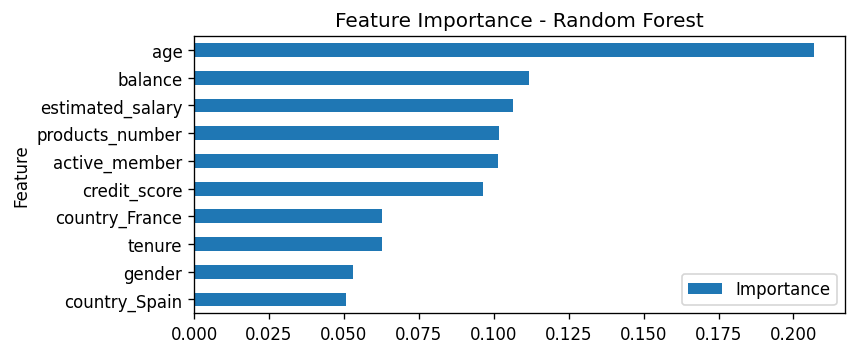

In [ ]:
# Importance of Feature
importances = rfc.feature_importances_
feat_imp = pd.DataFrame({
    "Feature": X_train_stdscal.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)
print(feat_imp)

import matplotlib.pyplot as plt
feat_imp.head(10).plot(
    x="Feature",
    y="Importance",
    kind="barh"
)
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.show()

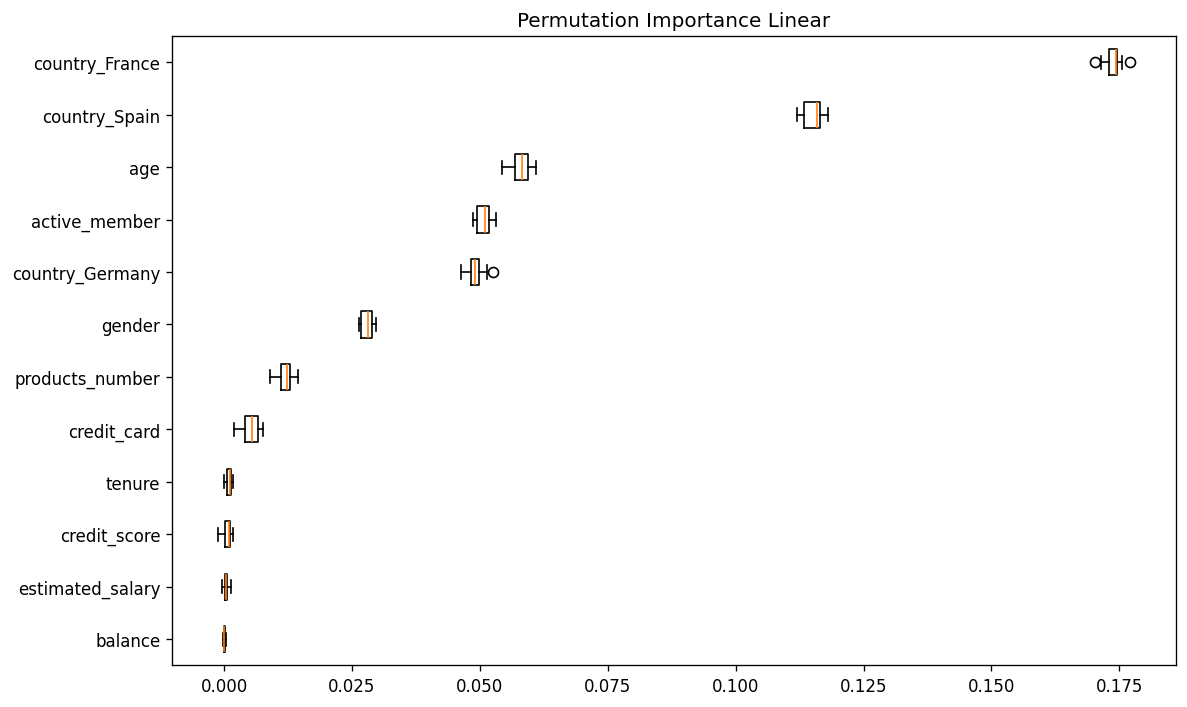

In [ ]:
from sklearn.inspection import permutation_importance
# Đảm bảo lr, X_train_stdscal và y_train_resample được định nghĩa
if 'lr' in locals() and 'X_train_stdscal' in locals() and 'y_train_resampled' in locals():
    # Tính toán Permutation Importance
    result = permutation_importance(
        lr, X_train_stdscal, y_train_resampled, n_repeats=10, random_state=0, n_jobs=-1
    )
    # Sắp xếp các biến theo mức độ quan trọng
    sorted_idx = result.importances_mean.argsort()
    # Vẽ biểu đồ Permutation Importance
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.boxplot(
        result.importances[sorted_idx].T,
        vert=False,
        tick_labels=X_train_stdscal.columns[sorted_idx],
    )
    ax.set_title("Permutation Importance Linear")
    fig.tight_layout()
    plt.show()
else:
    print("Các biến cần thiết (lr, X_train_stdscal, y_train_resample) không tìm thấy. Vui lòng chạy các ô trước đó.")

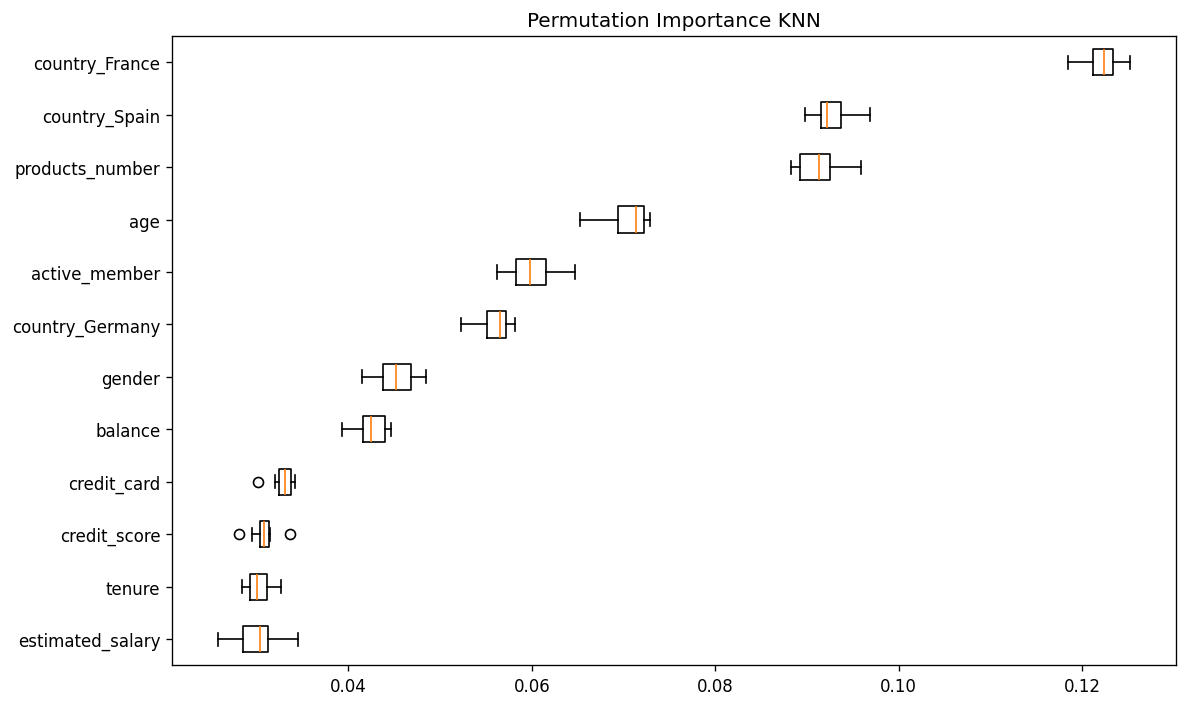

In [ ]:
# Đảm bảo best_dt_model, X_test và y_test được định nghĩa
if 'knn' in locals() and 'X_train_stdscal' in locals() and 'y_train_resampled' in locals():
    # Tính toán Permutation Importance
    result = permutation_importance(
        knn, X_train_stdscal, y_train_resampled, n_repeats=10, random_state=0, n_jobs=-1
    )
    # Sắp xếp các biến theo mức độ quan trọng
    sorted_idx = result.importances_mean.argsort()
    # Vẽ biểu đồ Permutation Importance
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.boxplot(
        result.importances[sorted_idx].T,
        vert=False,
        tick_labels=X_train_stdscal.columns[sorted_idx],
    )
    ax.set_title("Permutation Importance KNN")
    fig.tight_layout()
    plt.show()
else:
    print("Các biến cần thiết (knn, X_train_stdscal, y_train_resample) không tìm thấy. Vui lòng chạy các ô trước đó.")

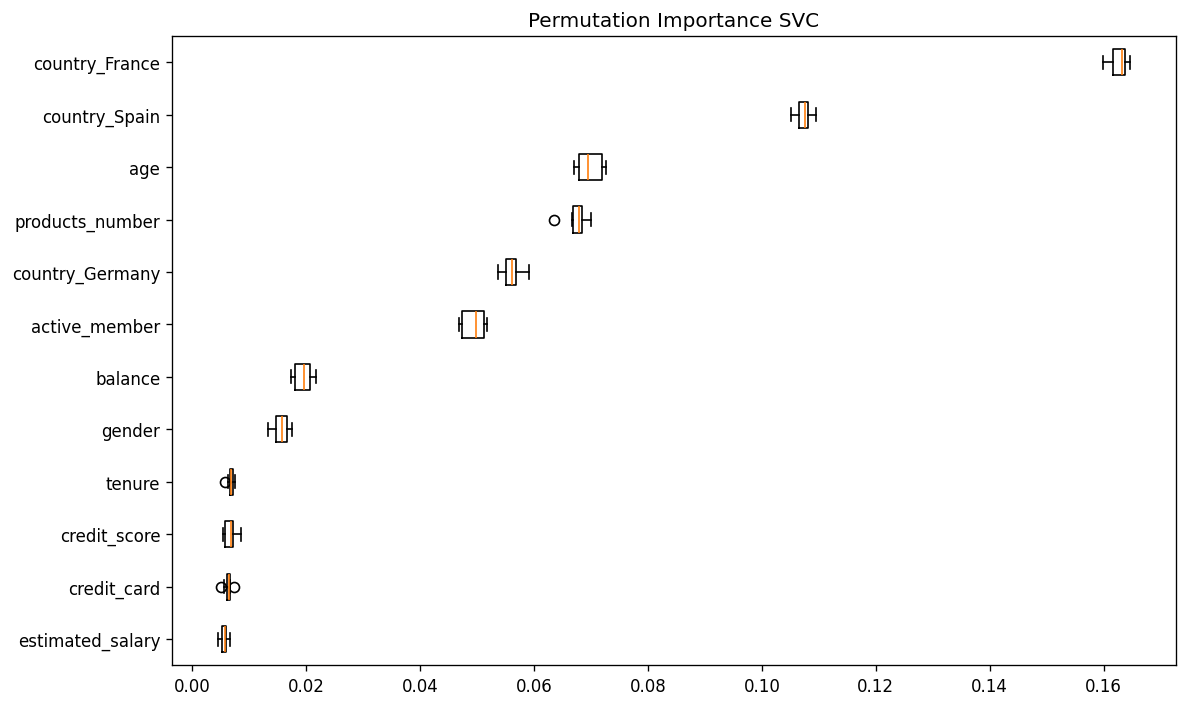

In [ ]:
# Đảm bảo best_dt_model, X_test và y_test được định nghĩa
if 'svc' in locals() and 'X_train_stdscal' in locals() and 'y_train_resampled' in locals():
    # Tính toán Permutation Importance
    result = permutation_importance(
        svc, X_train_stdscal, y_train_resampled, n_repeats=10, random_state=0, n_jobs=-1
    )
    # Sắp xếp các biến theo mức độ quan trọng
    sorted_idx = result.importances_mean.argsort()
    # Vẽ biểu đồ Permutation Importance
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.boxplot(
        result.importances[sorted_idx].T,
        vert=False,
        tick_labels=X_train_stdscal.columns[sorted_idx],
    )
    ax.set_title("Permutation Importance SVC")
    fig.tight_layout()
    plt.show()
else:
    print("Các biến cần thiết (svc, X_train_stdcal, y_train_resampled) không tìm thấy. Vui lòng chạy các ô trước đó.")

# Turning

### Tìm hyperparamater, training mô hình với tập X,y cũ

In [ ]:
# DECISION TREE
# ============================================================

from sklearn.model_selection import GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, 15, None],
}
dtc_tur = DecisionTreeClassifier(max_depth=5)
grid_search = GridSearchCV(estimator=dtc_tur,
                           param_grid=param_grid,
                           cv=5, #cv = cross validation
                           scoring='roc_auc',
                           n_jobs=-1,
                           verbose=1)
grid_search.fit(X_train_stdscal, y_train_resampled)

print(f"Bộ tham số tốt nhất: {grid_search.best_params_}")
print(f"Độ chính xác tốt nhất trên tập train: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Bộ tham số tốt nhất: {'criterion': 'gini', 'max_depth': 7}
Độ chính xác tốt nhất trên tập train: 0.8989


Mô hình Decision Tree đã được huấn luyện thành công.
Đánh giá mô hình Decision Tree:
Accuracy: 0.7820
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.81      0.86      1593
           1       0.47      0.67      0.56       407

    accuracy                           0.78      2000
   macro avg       0.69      0.74      0.71      2000
weighted avg       0.82      0.78      0.79      2000

Confusion Matrix:


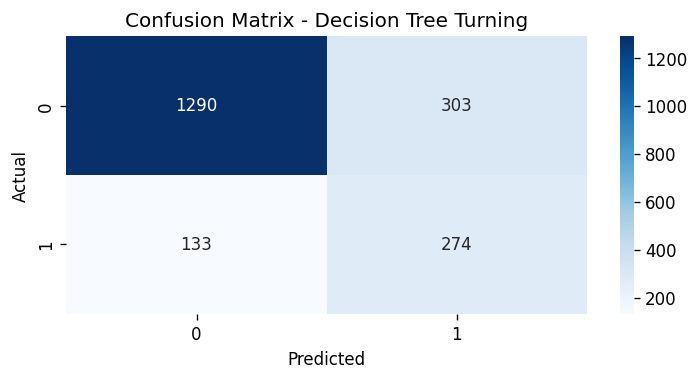

In [ ]:
# Khởi tạo mô hình Decision Tree

dtc_tur = DecisionTreeClassifier(criterion='gini', max_depth=7, random_state=42)

# Huấn luyện mô hình
dtc_tur.fit(X_train_stdscal, y_train_resampled)

# Dự đoán trên tập kiểm tra
y_pred_dtc_tur = dtc_tur.predict(X_test_stdscal)

print("Mô hình Decision Tree đã được huấn luyện thành công.")

# Đánh giá mô hình Decision Tree
print("Đánh giá mô hình Decision Tree:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dtc_tur):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_dtc_tur))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_dtc_tur), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree Turning')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# RANDOM FOREST
# ============================================================

rf_params = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None,5, 10, 20],
}

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params,
    cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1)

rf_gs.fit(X_train_stdscal, y_train_resampled)

print(f"\n  Best params  : {rf_gs.best_params_}")
print(f"  Best roc_auc : {rf_gs.best_score_:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits

  Best params  : {'max_depth': 20, 'n_estimators': 300}
  Best roc_auc : 0.9479


Mô hình Random Forest đã được huấn luyện thành công.

Đánh giá mô hình Random Forest:
Accuracy: 0.8375
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.90      1593
           1       0.60      0.58      0.59       407

    accuracy                           0.84      2000
   macro avg       0.75      0.74      0.75      2000
weighted avg       0.84      0.84      0.84      2000

Confusion Matrix:


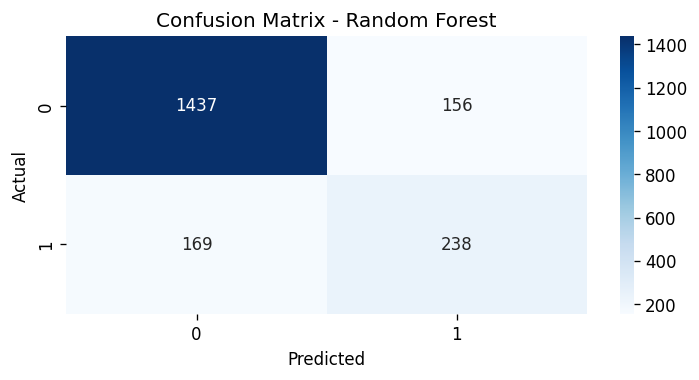

In [ ]:
# Khởi tạo mô hình Random Forest
rfc_tur = RandomForestClassifier(n_estimators=300, max_depth = 20, random_state=42)

# Huấn luyện mô hình
rfc_tur.fit(X_train_stdscal, y_train_resampled)

# Dự đoán trên tập kiểm tra
y_pred_rfc_tur = rfc_tur.predict(X_test_stdscal)

print("Mô hình Random Forest đã được huấn luyện thành công.")


# Đánh giá mô hình Random Forest
print("\nĐánh giá mô hình Random Forest:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rfc_tur):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rfc_tur))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_rfc_tur), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# LINEAR REGRESSION
# ============================================================
lr_params = {
    'C':        [0.01, 0.1, 1, 10, 100],
    'penalty':  ['l1', 'l2'],
}

lr_gs = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_params,
    cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1)

lr_gs.fit(X_train_stdscal, y_train_resampled)

print(f"\n  Best params  : {lr_gs.best_params_}")
print(f"  Best CV AUC  : {lr_gs.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits

  Best params  : {'C': 0.1, 'penalty': 'l2'}
  Best CV AUC  : 0.8931


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solver

Mô hình Logistic Regression đã được huấn luyện thành công.
Đánh giá mô hình Logistic Regression:
Accuracy: 0.7770
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1593
           1       0.45      0.47      0.46       407

    accuracy                           0.78      2000
   macro avg       0.66      0.66      0.66      2000
weighted avg       0.78      0.78      0.78      2000

Confusion Matrix:


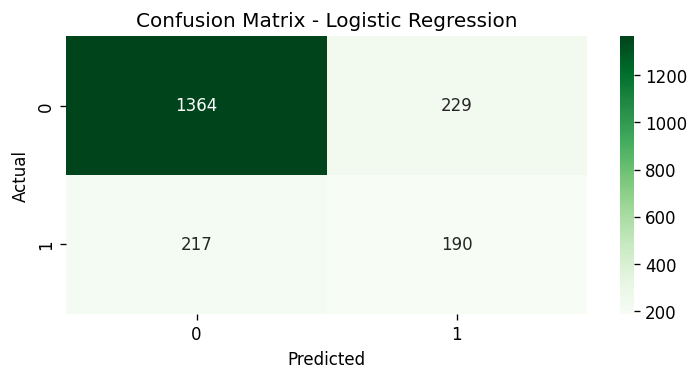

In [ ]:
# 3. Khởi tạo và huấn luyện mô hình Logistic Regression
lr_tur = LogisticRegression(C=0.1, penalty= 'l2', random_state=42)
lr_tur.fit(X_train_stdscal, y_train_resampled)

# Dự đoán trên tập kiểm tra
y_pred_lr_tur = lr_tur.predict(X_test_stdscal)

print("Mô hình Logistic Regression đã được huấn luyện thành công.")

# Đánh giá mô hình Logistic Regression
print("Đánh giá mô hình Logistic Regression:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr_tur):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr_tur))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_lr_tur), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# KNN
# ============================================================

knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
}

knn_gs = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1)

knn_gs.fit(X_train_stdscal, y_train_resampled)

print(f"\n  Best params  : {knn_gs.best_params_}")
print(f"  Best Roc_auc  : {knn_gs.best_score_:.4f}")


Fitting 5 folds for each of 7 candidates, totalling 35 fits

  Best params  : {'n_neighbors': 21}
  Best Roc_auc  : 0.9197


Mô hình KNN đã được huấn luyện thành công.
Đánh giá mô hình KNN:
Accuracy: 0.8135
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88      1593
           1       0.54      0.53      0.54       407

    accuracy                           0.81      2000
   macro avg       0.71      0.71      0.71      2000
weighted avg       0.81      0.81      0.81      2000

Confusion Matrix:


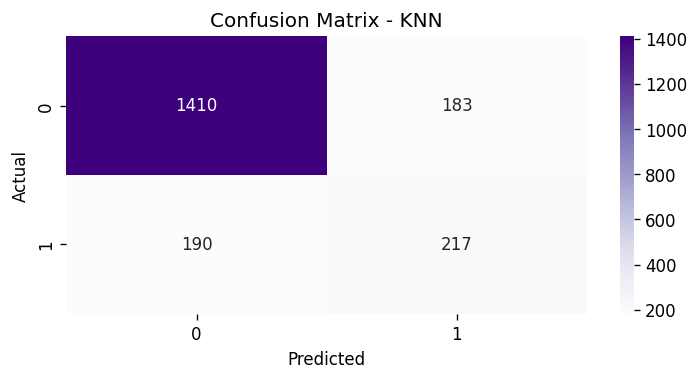

In [ ]:
# 4. Khởi tạo và huấn luyện mô hình K-Nearest Neighbors (KNN)
knn_tur = KNeighborsClassifier(n_neighbors=21)
knn_tur.fit(X_train_stdscal, y_train_resampled)

# Dự đoán trên tập kiểm tra
y_pred_knn_tur = knn_tur.predict(X_test_stdscal)

print("Mô hình KNN đã được huấn luyện thành công.")


# Đánh giá mô hình KNN
print("Đánh giá mô hình KNN:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn_tur):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_knn_tur))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_knn_tur), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# SVC
# ============================================================

svc_params = {
    'kernel': ['rbf', 'linear','poly' ,'sigmoid'],
}

svc_gs = GridSearchCV(
    SVC(probability=True, random_state=42),
    svc_params,
    cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1)

svc_gs.fit(X_train_stdscal, y_train_resampled)

print(f"\n  Best params  : {svc_gs.best_params_}")
print(f"  Best Roc_auc  : {svc_gs.best_score_:.4f}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits

  Best params  : {'kernel': 'rbf'}
  Best Accuracy  : 0.9324


Mô hình SVC đã được huấn luyện thành công.
Đánh giá mô hình SVC:
Accuracy: 0.8360
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.90      1593
           1       0.60      0.58      0.59       407

    accuracy                           0.84      2000
   macro avg       0.75      0.74      0.74      2000
weighted avg       0.83      0.84      0.84      2000

Confusion Matrix:


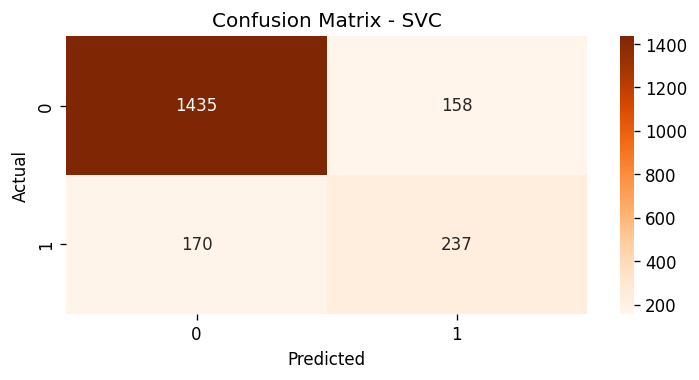

In [ ]:
# 5. Khởi tạo và huấn luyện mô hình Support Vector Classifier (SVC)
svc_tur = SVC(kernel = 'rbf', random_state=42, probability=True)
svc_tur.fit(X_train_stdscal, y_train_resampled)

# Dự đoán trên tập kiểm tra
y_pred_svc_tur = svc_tur.predict(X_test_stdscal)

print("Mô hình SVC đã được huấn luyện thành công.")

# Đánh giá mô hình SVC
print("Đánh giá mô hình SVC:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc_tur):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_svc_tur))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_svc_tur), annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - SVC')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Nhận xét**

Sau khi tìm Hyperparameters, mô hình Decision Tree đã cải thiện mạnh mẽ chỉ số Recall từ 0.59 lên 0.67. Đây hiện là mô hình có khả năng "tóm" được nhiều khách hàng rời bỏ nhất trong tất cả các mô hình.

### Bin các biến Numerical, tìm hyperparamater, giữ đầy đủ các biến để đưa vào mô hình

In [ ]:
# tạo df_turning từ tập X đã encoding
df_turning = X.copy()
df_turning.head()

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_France,country_Germany,country_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


In [ ]:
# ── 1. credit_score → theo thang FICO ───────────────────────
df_turning['credit_score_group'] = pd.cut(
    df_turning['credit_score'],
    bins=[0, 580, 670, 740, 800, 860],
    labels=[0, 1, 2, 3, 4],   # 0=Poor, 1=Fair, 2=Good, 3=Very Good, 4=Exceptional
    right=False
).astype(int)
df_turning.drop(columns=['credit_score'], inplace=True)

In [ ]:
 # ── 2. age → theo nhóm tuổi ─────────────────────────────────
df_turning['age_group'] = pd.cut(
    df_turning['age'],
    bins=[0, 30, 40, 50, 60, 100],
    labels=[0, 1, 2, 3, 4],   # 0=<30, 1=30-40, 2=40-50, 3=50-60, 4=>60
    right=False
).astype(int)

df_turning.drop(columns=['age'], inplace=True)

In [ ]:
# ── 3. estimated_salary → 4 nhóm đều nhau (quantile) ────────
# salary phân phối uniform → quantile cho bin cân bằng nhất
df_turning['salary_group'] = pd.qcut(
    df_turning['estimated_salary'],
    q=4,
    labels=[0, 1, 2, 3]       # 0=thấp nhất, 3=cao nhất
).astype(int)

df_turning.drop(columns=['estimated_salary'], inplace=True)

In [ ]:
# ── 4. balance → theo domain knowledge từ EDA ───────────────
df_turning['balance_group'] = pd.cut(
    df_turning['balance'],
    bins=[-1, 0, 50000, 100000, 150000, 300000],
    labels=[0, 1, 2, 3, 4],   # 0=0đ, 1=0-50k, 2=50-100k, 3=100-150k, 4=>150k
).astype(int)

df_turning.drop(columns=['balance'], inplace=True)

In [ ]:
df_turning

,gender,tenure,products_number,credit_card,active_member,country_France,country_Germany,country_Spain,credit_score_group,age_group,salary_group,balance_group
0,0,2,1,1,1,1,0,0,1,2,2,0
1,0,1,1,0,1,0,0,1,1,2,2,2
2,0,8,3,1,0,1,0,0,0,2,2,4
3,0,1,2,0,0,1,0,0,2,1,1,0
4,0,2,1,1,1,0,0,1,4,2,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1,5,2,1,0,1,0,0,3,1,1,0
9996,1,10,1,1,1,1,0,0,0,1,2,2
9997,0,7,1,0,1,1,0,0,2,1,0,0
9998,1,3,2,1,0,0,1,0,3,2,1,2


In [ ]:
# Chia lại X,y và train test

X_turning = df_turning.copy()
y_turning = y.copy()

X_train_tur, X_test_tur, y_train_tur, y_test_tur = train_test_split(X_turning, y_turning, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# xử lý imbalance

# Instantiate SMOTE
sm = SMOTE(random_state=42)

# Resample the training data
X_train_resampled1, y_train_resampled1 = sm.fit_resample(X_train_tur, y_train_tur)

print("Class distribution before oversampling (y_train):")
print(y_train.value_counts())
print("\nClass distribution after oversampling (y_train_resampled):")
print(y_train_resampled.value_counts())

Class distribution before oversampling (y_train):
churn
0    6370
1    1630
Name: count, dtype: int64

Class distribution after oversampling (y_train_resampled):
churn
1    6370
0    6370
Name: count, dtype: int64


#### Evaluation

In [ ]:
# DECISION TREE
# ============================================================
from sklearn.model_selection import GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, 15, None],
}
dtc_tur = DecisionTreeClassifier(max_depth=5)
grid_search = GridSearchCV(estimator=dtc_tur,
                           param_grid=param_grid,
                           cv=5, #cv = cross validation
                           scoring='roc_auc',
                           n_jobs=-1,
                           verbose=1)
grid_search.fit(X_train_resampled1, y_train_resampled1)

print(f"Bộ tham số tốt nhất: {grid_search.best_params_}")
print(f"Độ chính xác tốt nhất trên tập train: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Bộ tham số tốt nhất: {'criterion': 'entropy', 'max_depth': 10}
Độ chính xác tốt nhất trên tập train: 0.8827


Mô hình Decision Tree đã được huấn luyện thành công.
Đánh giá mô hình Decision Tree:
Accuracy: 0.8495
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1593
           1       0.69      0.48      0.56       407

    accuracy                           0.85      2000
   macro avg       0.78      0.71      0.74      2000
weighted avg       0.84      0.85      0.84      2000

Confusion Matrix:


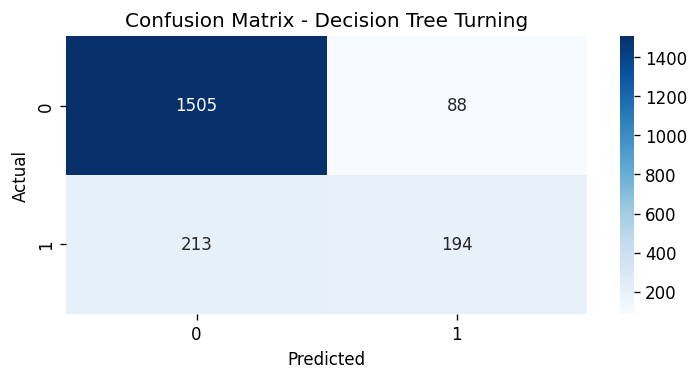

In [ ]:
# Khởi tạo mô hình Decision Tree

dtc_tur = DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42)

# Huấn luyện mô hình
dtc_tur.fit(X_train_tur, y_train_tur)

# Dự đoán trên tập kiểm tra
y_pred_dtc_tur = dtc_tur.predict(X_test_tur)

print("Mô hình Decision Tree đã được huấn luyện thành công.")

# Đánh giá mô hình Decision Tree
print("Đánh giá mô hình Decision Tree:")
print(f"Accuracy: {accuracy_score(y_test_tur, y_pred_dtc_tur):.4f}")
print("Classification Report:")
print(classification_report(y_test_tur, y_pred_dtc_tur))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test_tur, y_pred_dtc_tur), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree Turning')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# 3. RANDOM FOREST
# ============================================================

rf_params = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None,5, 10, 20],
}

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params,
    cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1)

rf_gs.fit(X_train_resampled1, y_train_resampled1)

print(f"\n  Best params  : {rf_gs.best_params_}")
print(f"  Best Roc_auc : {rf_gs.best_score_:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits

  Best params  : {'max_depth': 20, 'n_estimators': 300}
  Best Roc_auc : 0.9447


Mô hình Random Forest đã được huấn luyện thành công.

Đánh giá mô hình Random Forest:
Accuracy: 0.8040
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.86      0.87      1593
           1       0.52      0.60      0.55       407

    accuracy                           0.80      2000
   macro avg       0.70      0.73      0.71      2000
weighted avg       0.82      0.80      0.81      2000

Confusion Matrix:


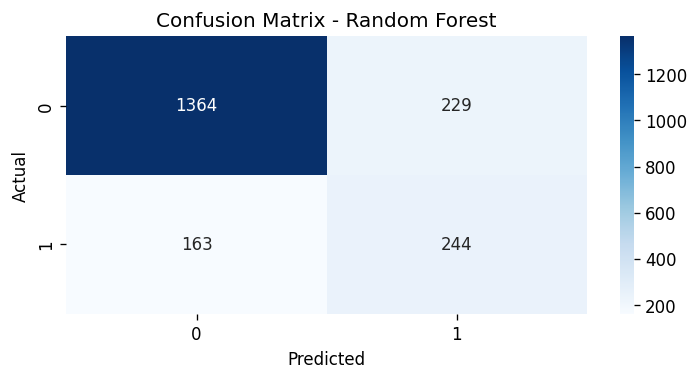

In [ ]:
# Khởi tạo mô hình Random Forest
rfc_tur = RandomForestClassifier(n_estimators=300, max_depth = 20,random_state=42)

# Huấn luyện mô hình
rfc_tur.fit(X_train_resampled1, y_train_resampled1)

# Dự đoán trên tập kiểm tra
y_pred_rfc_tur = rfc_tur.predict(X_test_tur)

print("Mô hình Random Forest đã được huấn luyện thành công.")


# Đánh giá mô hình Random Forest
print("\nĐánh giá mô hình Random Forest:")
print(f"Accuracy: {accuracy_score(y_test_tur, y_pred_rfc_tur):.4f}")
print("Classification Report:")
print(classification_report(y_test_tur, y_pred_rfc_tur))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test_tur, y_pred_rfc_tur), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# LINEAR REGRESSION
# ============================================================
lr_params = {
    'C':        [0.01, 0.1, 1, 10, 100],
    'penalty':  ['l1', 'l2'],
}

lr_gs = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_params,
    cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1)

lr_gs.fit(X_train_resampled1, y_train_resampled1)

print(f"\n  Best params  : {lr_gs.best_params_}")
print(f"  Best CV AUC  : {lr_gs.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits

  Best params  : {'C': 10, 'penalty': 'l2'}
  Best CV AUC  : 0.7914


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solver

Mô hình Logistic Regression đã được huấn luyện thành công.
Đánh giá mô hình Logistic Regression:
Accuracy: 0.7380
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1593
           1       0.40      0.58      0.48       407

    accuracy                           0.74      2000
   macro avg       0.64      0.68      0.65      2000
weighted avg       0.78      0.74      0.75      2000

Confusion Matrix:


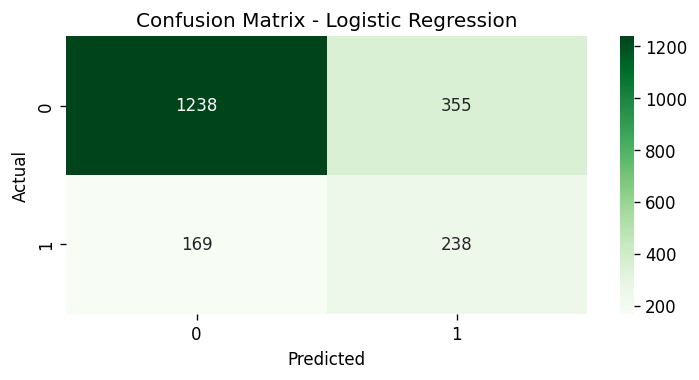

In [ ]:
# 3. Khởi tạo và huấn luyện mô hình Logistic Regression
lr_tur = LogisticRegression(C=10, penalty= 'l2', random_state=42)
lr_tur.fit(X_train_resampled1, y_train_resampled1)

# Dự đoán trên tập kiểm tra
y_pred_lr_tur = lr_tur.predict(X_test_tur)

print("Mô hình Logistic Regression đã được huấn luyện thành công.")

# Đánh giá mô hình Logistic Regression
print("Đánh giá mô hình Logistic Regression:")
print(f"Accuracy: {accuracy_score(y_test_tur, y_pred_lr_tur):.4f}")
print("Classification Report:")
print(classification_report(y_test_tur, y_pred_lr_tur))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test_tur, y_pred_lr_tur), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# 2. KNN
# ============================================================

knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
}

knn_gs = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1)

knn_gs.fit(X_train_resampled1, y_train_resampled1)

print(f"\n  Best params  : {knn_gs.best_params_}")
print(f"  Best Roc_auc  : {knn_gs.best_score_:.4f}")

Fitting 5 folds for each of 7 candidates, totalling 35 fits

  Best params  : {'n_neighbors': 5}
  Best Roc_auc  : 0.9144


Mô hình KNN đã được huấn luyện thành công.
Đánh giá mô hình KNN:
Accuracy: 0.7590
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      1593
           1       0.43      0.57      0.49       407

    accuracy                           0.76      2000
   macro avg       0.65      0.69      0.67      2000
weighted avg       0.79      0.76      0.77      2000

Confusion Matrix:


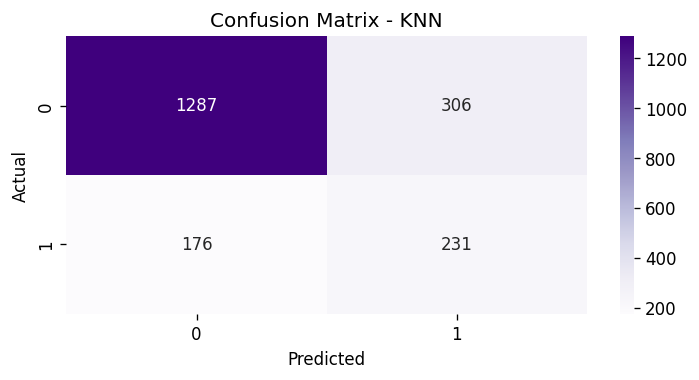

In [ ]:
# 4. Khởi tạo và huấn luyện mô hình K-Nearest Neighbors (KNN)
knn_tur = KNeighborsClassifier(n_neighbors=5)
knn_tur.fit(X_train_resampled1, y_train_resampled1)

# Dự đoán trên tập kiểm tra
y_pred_knn_tur = knn_tur.predict(X_test_tur)

print("Mô hình KNN đã được huấn luyện thành công.")


# Đánh giá mô hình KNN
print("Đánh giá mô hình KNN:")
print(f"Accuracy: {accuracy_score(y_test_tur, y_pred_knn_tur):.4f}")
print("Classification Report:")
print(classification_report(y_test_tur, y_pred_knn_tur))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test_tur, y_pred_knn_tur), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
svc_params = {'kernel': ['rbf', 'linear'],}

svc_gs = GridSearchCV(
    SVC(probability=True, random_state=42),
    svc_params,
    cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1)

svc_gs.fit(X_train_resampled1, y_train_resampled1)

print(f"\n  Best params  : {svc_gs.best_params_}")
print(f"  Best Roc_auc  : {svc_gs.best_score_:.4f}")

Fitting 5 folds for each of 2 candidates, totalling 10 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



  Best params  : {'kernel': 'rbf'}
  Best Roc_auc  : 0.8716


Mô hình SVC đã được huấn luyện thành công.
Đánh giá mô hình SVC:
Accuracy: 0.7780
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.82      0.85      1593
           1       0.47      0.62      0.53       407

    accuracy                           0.78      2000
   macro avg       0.68      0.72      0.69      2000
weighted avg       0.81      0.78      0.79      2000

Confusion Matrix:


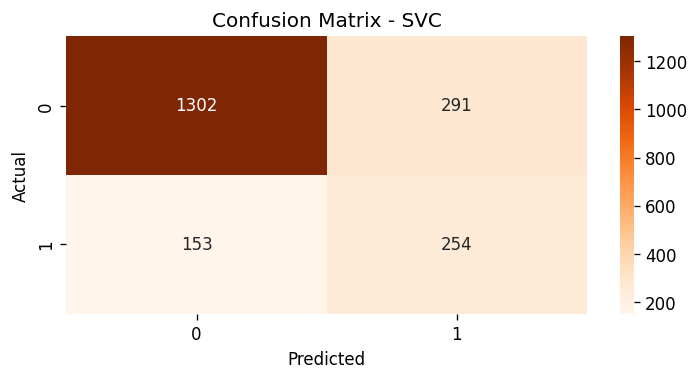

In [ ]:
# 5. Khởi tạo và huấn luyện mô hình Support Vector Classifier (SVC)
svc_tur = SVC(kernel = 'rbf', random_state=42, probability=True)
svc_tur.fit(X_train_resampled1, y_train_resampled1)

# Dự đoán trên tập kiểm tra
y_pred_svc_tur = svc_tur.predict(X_test_tur)

print("Mô hình SVC đã được huấn luyện thành công.")

# Đánh giá mô hình SVC
print("Đánh giá mô hình SVC:")
print(f"Accuracy: {accuracy_score(y_test_tur, y_pred_svc_tur):.4f}")
print("Classification Report:")
print(classification_report(y_test_tur, y_pred_svc_tur))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test_tur, y_pred_svc_tur), annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - SVC')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Nhận xét**

- Việc chia nhóm các biến số (tuổi, số dư...) đã giúp Decision Tree đạt độ chính xác cực cao (~85%) và độ tin cậy khi dự đoán (Precision) lên tới 0.69 nhưng chỉ số Recall chỉ có 0.48

- SVC là mô hình bắt được nhiều khách hàng rời bỏ nhất (Recall 0.62).

### Lựa chọn lại biến, bin các biến Numerical, tìm hyperparamater

**Các biến ít quan trọng nhất đến các mô hình:**
- dtc : country, **tenure**, gender,**credit_card**
- rfc: country,**tenure**, gender,**credit_card**
- lr: **tenure**, credit_score, estimated_salary, balance
- knn: **credit_card**, credit_score, **tenure**, estimated-salary
- svc: **tenure**, credit_score, **credit_card**, estimated_salary

--> - Hai biến `tenure`,`credit_card` ít quan trọng với hầu hết các mô hình sự báo nên loại bỏ 2 biến này khỏi mô hình. Các biến còn lại không loại bỏ vì có thể chúng ít quan trọng trong mô hình này nhưng lại quan trọng trong mô hình khác

In [ ]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
X.head()

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_France,country_Germany,country_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


In [ ]:
X_train_resampled.head()

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_France,country_Germany,country_Spain
0,753,1,57,7,0.00,1,1,0,159475.08,1,0,0
1,739,1,32,3,102128.27,1,1,0,63981.37,0,1,0
2,755,0,37,0,113865.23,2,1,1,117396.25,0,1,0
3,561,1,37,5,0.00,2,1,0,83093.25,1,0,0
4,692,1,49,6,110540.43,2,0,1,107472.99,0,1,0


In [ ]:
# tạo df_turning từ tập X đã encoding
df_turning = X.copy()
df_turning.head()

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_France,country_Germany,country_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


In [ ]:
# Drop tenure và credit_card
df_turning = df_turning.drop(['tenure','credit_card'], axis =1)

In [ ]:
df_turning.head(3)

,credit_score,gender,age,balance,products_number,active_member,estimated_salary,country_France,country_Germany,country_Spain
0,619,0,42,0.00,1,1,101348.88,1,0,0
1,608,0,41,83807.86,1,1,112542.58,0,0,1
2,502,0,42,159660.80,3,0,113931.57,1,0,0


In [ ]:
# ── 1. credit_score → theo thang FICO ───────────────────────
df_turning['credit_score_group'] = pd.cut(
    df_turning['credit_score'],
    bins=[0, 580, 670, 740, 800, 860],
    labels=[0, 1, 2, 3, 4],   # 0=Poor, 1=Fair, 2=Good, 3=Very Good, 4=Exceptional
    right=False
).astype(int)
df_turning.drop(columns=['credit_score'], inplace=True)

In [ ]:
 # ── 2. age → theo nhóm tuổi ─────────────────────────────────
df_turning['age_group'] = pd.cut(
    df_turning['age'],
    bins=[0, 30, 40, 50, 60, 100],
    labels=[0, 1, 2, 3, 4],   # 0=<30, 1=30-40, 2=40-50, 3=50-60, 4=>60
    right=False
).astype(int)

df_turning.drop(columns=['age'], inplace=True)

In [ ]:
# ── 3. estimated_salary → 4 nhóm đều nhau (quantile) ────────
# salary phân phối uniform → quantile cho bin cân bằng nhất
df_turning['salary_group'] = pd.qcut(
    df_turning['estimated_salary'],
    q=4,
    labels=[0, 1, 2, 3]       # 0=thấp nhất, 3=cao nhất
).astype(int)

df_turning.drop(columns=['estimated_salary'], inplace=True)

In [ ]:
# ── 4. balance → theo domain knowledge từ EDA ───────────────
df_turning['balance_group'] = pd.cut(
    df_turning['balance'],
    bins=[-1, 0, 50000, 100000, 150000, 300000],
    labels=[0, 1, 2, 3, 4],   # 0=0đ, 1=0-50k, 2=50-100k, 3=100-150k, 4=>150k
).astype(int)

df_turning.drop(columns=['balance'], inplace=True)

In [ ]:
df_turning

,gender,products_number,active_member,country_France,country_Germany,country_Spain,credit_score_group,age_group,salary_group,balance_group
0,0,1,1,1,0,0,1,2,2,0
1,0,1,1,0,0,1,1,2,2,2
2,0,3,0,1,0,0,0,2,2,4
3,0,2,0,1,0,0,2,1,1,0
4,0,1,1,0,0,1,4,2,1,3
...,...,...,...,...,...,...,...,...,...,...
9995,1,2,0,1,0,0,3,1,1,0
9996,1,1,1,1,0,0,0,1,2,2
9997,0,1,1,1,0,0,2,1,0,0
9998,1,2,0,0,1,0,3,2,1,2


In [ ]:
# Chia lại X,y và train test

X_turning = df_turning.copy()
y_turning = y.copy()

X_train_tur, X_test_tur, y_train_tur, y_test_tur = train_test_split(X_turning, y_turning, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# xử lý imbalance

# Instantiate SMOTE
sm = SMOTE(random_state=42)

# Resample the training data
X_train_resampled1, y_train_resampled1 = sm.fit_resample(X_train_tur, y_train_tur)

print("Class distribution before oversampling (y_train):")
print(y_train.value_counts())
print("\nClass distribution after oversampling (y_train_resampled):")
print(y_train_resampled.value_counts())

Class distribution before oversampling (y_train):
churn
0    6370
1    1630
Name: count, dtype: int64

Class distribution after oversampling (y_train_resampled):
churn
1    6370
0    6370
Name: count, dtype: int64


#### Evaluation

In [ ]:

from sklearn.model_selection import GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, 15, None],
}
dtc_tur = DecisionTreeClassifier(max_depth=5)
grid_search = GridSearchCV(estimator=dtc_tur,
                           param_grid=param_grid,
                           cv=5, #cv = cross validation
                           scoring='roc_auc',
                           n_jobs=-1,
                           verbose=1)
grid_search.fit(X_train_resampled1, y_train_resampled1)

print(f"Bộ tham số tốt nhất: {grid_search.best_params_}")
print(f"Độ chính xác tốt nhất trên tập train: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Bộ tham số tốt nhất: {'criterion': 'entropy', 'max_depth': 10}
Độ chính xác tốt nhất trên tập train: 0.8787


In [ ]:
# Khởi tạo mô hình Decision Tree
dtc_tur = DecisionTreeClassifier(criterion= 'entropy', max_depth= 10,random_state=42)

# Huấn luyện mô hình
dtc_tur.fit(X_train_resampled1, y_train_resampled1)

# Dự đoán trên tập kiểm tra
y_pred_dtc_tur = dtc_tur.predict(X_test_tur)

print("Mô hình Decision Tree đã được huấn luyện thành công.")

Mô hình Decision Tree đã được huấn luyện thành công.


Đánh giá mô hình Decision Tree:
Accuracy: 0.7540
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.77      0.83      1593
           1       0.43      0.69      0.53       407

    accuracy                           0.75      2000
   macro avg       0.67      0.73      0.68      2000
weighted avg       0.81      0.75      0.77      2000

Confusion Matrix:


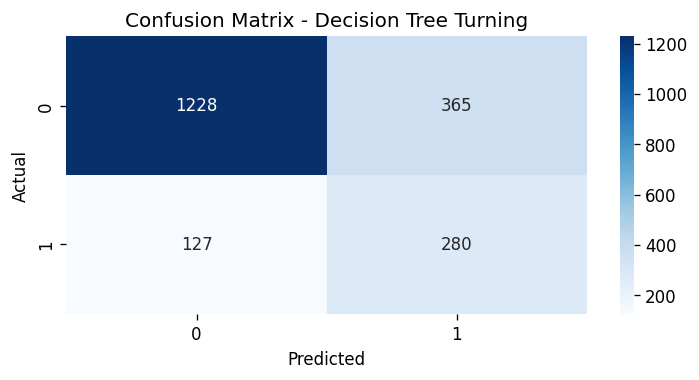

In [ ]:
# Đánh giá mô hình Decision Tree
print("Đánh giá mô hình Decision Tree:")
print(f"Accuracy: {accuracy_score(y_test_tur, y_pred_dtc_tur):.4f}")
print("Classification Report:")
print(classification_report(y_test_tur, y_pred_dtc_tur))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test_tur, y_pred_dtc_tur), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree Turning')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# 3. RANDOM FOREST
# ============================================================

rf_params = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None,5, 10, 20],
}

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params,
    cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1)

rf_gs.fit(X_train_resampled1, y_train_resampled1)

print(f"\n  Best params  : {rf_gs.best_params_}")
print(f"  Best Roc_auc : {rf_gs.best_score_:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



  Best params  : {'max_depth': None, 'n_estimators': 300}
  Best Roc_auc : 0.9131


Mô hình Random Forest đã được huấn luyện thành công.

Đánh giá mô hình Random Forest:
Accuracy: 0.7765
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.81      0.85      1593
           1       0.46      0.63      0.53       407

    accuracy                           0.78      2000
   macro avg       0.68      0.72      0.69      2000
weighted avg       0.81      0.78      0.79      2000

Confusion Matrix:


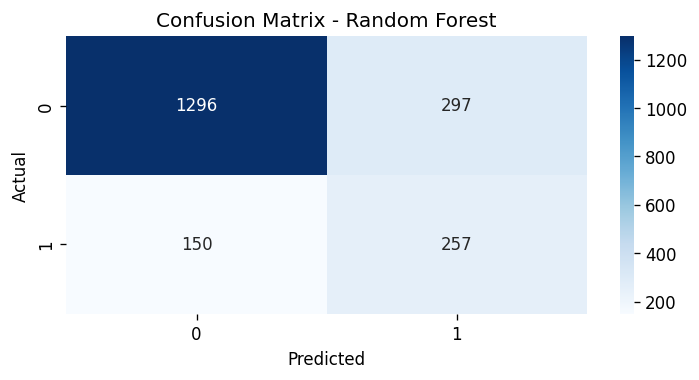

In [ ]:
# Khởi tạo mô hình Random Forest
rfc_tur = RandomForestClassifier(n_estimators=300, max_depth = None,random_state=42)

# Huấn luyện mô hình
rfc_tur.fit(X_train_resampled1, y_train_resampled1)

# Dự đoán trên tập kiểm tra
y_pred_rfc_tur = rfc_tur.predict(X_test_tur)

print("Mô hình Random Forest đã được huấn luyện thành công.")


# Đánh giá mô hình Random Forest
print("\nĐánh giá mô hình Random Forest:")
print(f"Accuracy: {accuracy_score(y_test_tur, y_pred_rfc_tur):.4f}")
print("Classification Report:")
print(classification_report(y_test_tur, y_pred_rfc_tur))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test_tur, y_pred_rfc_tur), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# LINEAR REGRESSION
# ============================================================
lr_params = {
    'C':        [0.01, 0.1, 1, 10, 100],
    'penalty':  ['l1', 'l2'],
}

lr_gs = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_params,
    cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1)

lr_gs.fit(X_train_resampled1, y_train_resampled1)

print(f"\n  Best params  : {lr_gs.best_params_}")
print(f"  Best CV AUC  : {lr_gs.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits

  Best params  : {'C': 10, 'penalty': 'l2'}
  Best CV AUC  : 0.7914


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solver

Mô hình Logistic Regression đã được huấn luyện thành công.
Đánh giá mô hình Logistic Regression:
Accuracy: 0.7175
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.73      0.81      1593
           1       0.39      0.66      0.49       407

    accuracy                           0.72      2000
   macro avg       0.64      0.70      0.65      2000
weighted avg       0.79      0.72      0.74      2000

Confusion Matrix:


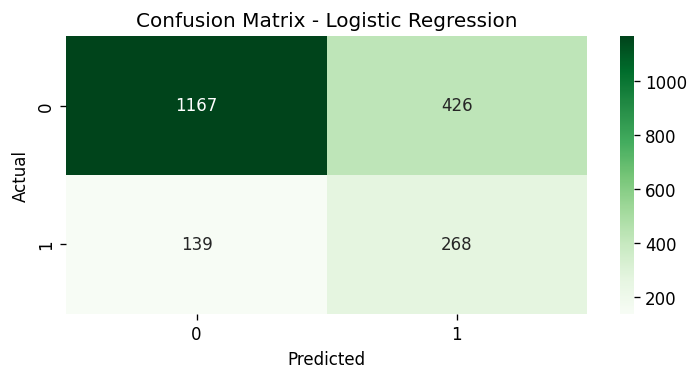

In [ ]:
# 3. Khởi tạo và huấn luyện mô hình Logistic Regression
lr_tur = LogisticRegression(C=10, penalty= 'l2', random_state=42)
lr_tur.fit(X_train_resampled1, y_train_resampled1)

# Dự đoán trên tập kiểm tra
y_pred_lr_tur = lr_tur.predict(X_test_tur)

print("Mô hình Logistic Regression đã được huấn luyện thành công.")

# Đánh giá mô hình Logistic Regression
print("Đánh giá mô hình Logistic Regression:")
print(f"Accuracy: {accuracy_score(y_test_tur, y_pred_lr_tur):.4f}")
print("Classification Report:")
print(classification_report(y_test_tur, y_pred_lr_tur))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test_tur, y_pred_lr_tur), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# 2. KNN
# ============================================================

knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
}

knn_gs = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1)

knn_gs.fit(X_train_resampled1, y_train_resampled1)

print(f"\n  Best params  : {knn_gs.best_params_}")
print(f"  Best Roc_auc  : {knn_gs.best_score_:.4f}")


Fitting 5 folds for each of 7 candidates, totalling 35 fits

  Best params  : {'n_neighbors': 9}
  Best Roc_auc  : 0.8901


Mô hình KNN đã được huấn luyện thành công.
Đánh giá mô hình KNN:
Accuracy: 0.7900
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.84      0.86      1593
           1       0.49      0.58      0.53       407

    accuracy                           0.79      2000
   macro avg       0.69      0.71      0.70      2000
weighted avg       0.81      0.79      0.80      2000

Confusion Matrix:


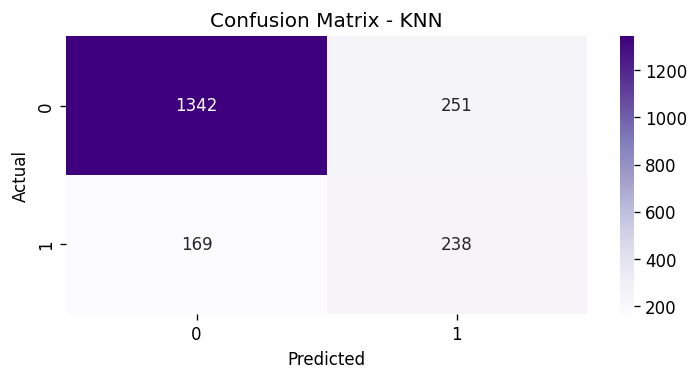

In [ ]:
# 4. Khởi tạo và huấn luyện mô hình K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train_resampled1, y_train_resampled1)

# Dự đoán trên tập kiểm tra
y_pred_knn_turn = knn.predict(X_test_tur)

print("Mô hình KNN đã được huấn luyện thành công.")


# Đánh giá mô hình KNN
print("Đánh giá mô hình KNN:")
print(f"Accuracy: {accuracy_score(y_test_tur, y_pred_knn_turn):.4f}")
print("Classification Report:")
print(classification_report(y_test_tur, y_pred_knn_turn))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test_tur, y_pred_knn_turn), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
svc_params = {
    'kernel': ['rbf', 'linear', 'poly' ,'sigmoid'],
}
svc_gs = GridSearchCV(
    SVC(probability=True, random_state=42),
    svc_params,
    cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1)

svc_gs.fit(X_train_resampled1, y_train_resampled1)

print(f"\n  Best params  : {svc_gs.best_params_}")
print(f"  Best Roc_auc  : {svc_gs.best_score_:.4f}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits

  Best params  : {'kernel': 'rbf'}
  Best Roc_auc  : 0.8716


Mô hình SVC đã được huấn luyện thành công.
Đánh giá mô hình SVC:
Accuracy: 0.7990
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      1593
           1       0.50      0.73      0.60       407

    accuracy                           0.80      2000
   macro avg       0.71      0.77      0.73      2000
weighted avg       0.84      0.80      0.81      2000

Confusion Matrix:


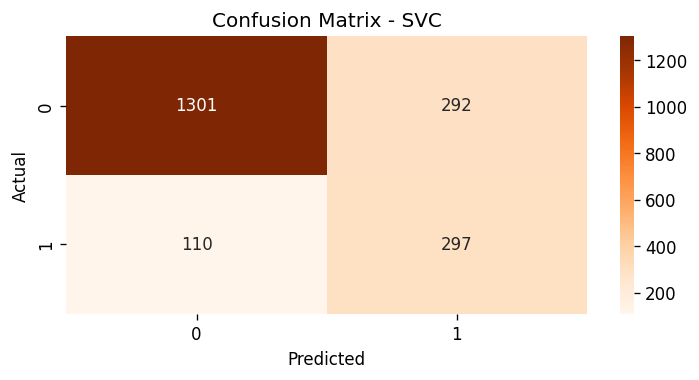

In [ ]:
# Khởi tạo và huấn luyện mô hình Support Vector Classifier (SVC)
svc_tur = SVC(kernel = 'rbf', random_state=42, probability=True)
svc_tur.fit(X_train_resampled1, y_train_resampled1)

# Dự đoán trên tập kiểm tra
y_pred_svc_tur = svc_tur.predict(X_test_tur)

print("Mô hình SVC đã được huấn luyện thành công.")

# Đánh giá mô hình SVC
print("Đánh giá mô hình SVC:")
print(f"Accuracy: {accuracy_score(y_test_tur, y_pred_svc_tur):.4f}")
print("Classification Report:")
print(classification_report(y_test_tur, y_pred_svc_tur))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test_tur, y_pred_svc_tur), annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - SVC')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## **KẾT LUẬN**

- Trong ngân hàng, chi phí để mất một khách hàng lớn hơn nhiều so với việc tặng nhầm một mã giảm giá. SVC bắt được tới 73% khách hàng sắp rời đi, đây là con số cao nhất trong tất cả các lần thử nghiệm.

- Lọc nhiễu thành công: Việc loại bỏ các biến ít quan trọng như thâm niên và thẻ tín dụng đã giúp SVC tập trung vào những yếu tố then chốt như Độ tuổi, Địa lý (Đức) và Số dư tài khoản.

- SVC giúp ngân hàng ngăn chặn tối đa việc thất thoát doanh thu trong khi vẫn giữ được độ tin cậy ổn định (F1-score 0.60).